# Демонстрационный ноутбук проекта

Этот ноутбук нужен как единая витрина проекта и как рабочая основа для подготовки текста ВКР.

Что делает ноутбук:
1. Коротко объясняет постановку задачи и сравниваемые алгоритмы.
2. Позволяет запустить один показательный эксперимент или использовать уже сохраненный бэкап.
3. Показывает примеры сигналов и итоговые метрики.
4. Собирает результаты всех сохраненных экспериментов в общую аналитическую таблицу.
5. Делает три уровня сравнения:
   - сначала Neural Viterbi vs Neural BCJR;
   - затем neural-подходы vs классические аналоги;
   - затем общее сравнение всех 4 алгоритмов.

Главная логика ноутбука соответствует ТЗ: в работе нужно разработать и исследовать Neural Viterbi и Neural BCJR, а также сравнить их по качеству декодирования и вычислительной сложности. Дополнительное сравнение с классическими Viterbi и BCJR здесь оставлено как важный контекст и как контрольная линия исследования.


## Что именно сравнивается

В проекте рассматриваются четыре алгоритма:

1. **Viterbi** - классический алгоритм поиска наиболее вероятного пути по trellis.
2. **BCJR** - классический алгоритм soft-декодирования, который работает с апостериорными вероятностями.
3. **Neural Viterbi** - обучаемая модификация, в которой neural-блок калибрует входные метрики, а затем используется trellis-декодирование.
4. **Neural BCJR** - обучаемая модификация, в которой neural-блок калибрует soft-информацию перед классическим BCJR.

Важно: по ТЗ главный акцент делается именно на **сравнение двух neural-подходов** - Neural Viterbi и Neural BCJR. Поэтому в аналитической части этого ноутбука они рассматриваются в первую очередь. Сравнение с классическими алгоритмами вынесено во второй и третий аналитические блоки.


## Уровни и сценарии

Для удобства показа сценарии разделены на четыре уровня:

- **Level 1** - быстрый учебный прогон. Нужен, чтобы быстро показать полный pipeline.
- **Level 2** - основной исследовательский режим. Здесь сетка SNR уже плотнее, а статистика надёжнее.
- **Level 3** - усложнённые каналы и model mismatch умеренной тяжести.
- **Level 4** - самые жёсткие сценарии. Здесь мы специально усиливаем mismatch и редкие тяжёлые искажения.

В демонстрационном наборе используются такие сценарии:
- `awgn` - базовый BPSK + AWGN;
- `rayleigh` - BPSK + Rayleigh fading + AWGN;
- `burst` - пакетные всплески шума;
- `noise_mismatch` - декодер использует неверную оценку дисперсии шума;
- `amplitude_mismatch` - сигнал приходит с другой амплитудой, чем ожидает формула LLR;
- `rayleigh_mismatch` - декодер игнорирует замирание канала при вычислении LLR;
- `impulsive_mismatch` - редкие сильные импульсные помехи, о которых декодер не знает.

Практический смысл уровней такой:
- **Level 1-2** показывают, как ведут себя алгоритмы на относительно простых условиях;
- **Level 3-4** нужны, чтобы проверить устойчивость при более реалистичных и тяжёлых искажениях.


## 1. Импорт библиотек и подготовка окружения

В этой секции мы:
- находим корень проекта;
- подключаем основной пакет `comm_ai`;
- подключаем вспомогательные функции;
- проверяем, доступны ли интерактивные виджеты.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import HTML, Markdown, display

# Поиск корня репозитория относительно папки `для_показа`.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

# Подключаем пакет проекта и вспомогательный слой для показа.
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except Exception:
    widgets = None
    WIDGETS_AVAILABLE = False

from demo_helpers import (
    BACKUP_RESULTS,
    CHANNEL_DESCRIPTIONS,
    LEVEL_DESCRIPTIONS,
    PRESETS,
    aggregate_demo_results,
    automatic_commentary,
    build_custom_preset,
    ensure_default_backups,
    export_config_examples,
    filter_results,
    list_available_runs,
    parameter_reference,
    presets_table,
    run_demo_experiment,
)
from comm_ai.datasets.signals_dataset import SignalsDataset
from comm_ai.utils.io import load_yaml

print('[1/7] Окружение подготовлено.')
print('Корень проекта:', ROOT)
print('Папка с бэкапами:', BACKUP_RESULTS)
print('ipywidgets доступны:', WIDGETS_AVAILABLE)


[1/7] Окружение подготовлено.
Корень проекта: c:\Users\maks\Desktop\maga\диплом\практика\3\Хахин М.С
Папка с бэкапами: C:\Users\maks\Desktop\maga\диплом\практика\3\Хахин М.С\для запуска\backups\results
ipywidgets доступны: True


## 2. Таблица готовых preset-сценариев

Ниже показаны preset-конфигурации, которые уже подготовлены для показа.

Логика такая:
- если нужный бэкап уже существует, его можно сразу использовать;
- если бэкапа нет, тот же preset можно запустить и сохранить как новый результат.


In [2]:
export_config_examples()
print('[2/7] Список preset-сценариев:')
display(presets_table())


[2/7] Список preset-сценариев:


,preset,level,scenario,K,num_blocks,snr_db_list,epochs,description
0,level_1_awgn_fast,level_1,awgn,32,10,"[0, 2, 4]",1,"BPSK + AWGN. Базовый учебный сценарий, в котор..."
1,level_2_awgn_dense,level_2,awgn,64,20,"[0, 1, 2, 3, 4]",2,"BPSK + AWGN. Базовый учебный сценарий, в котор..."
2,level_3_rayleigh,level_3,rayleigh,64,16,"[0, 2, 4]",2,BPSK + Rayleigh fading + AWGN. Канал с замиран...
3,level_3_burst,level_3,burst,64,16,"[0, 2, 4]",2,BPSK + AWGN с пакетными всплесками шума. Ошибк...
4,level_3_noise_mismatch,level_3,noise_mismatch,64,16,"[0, 2, 4]",2,"BPSK + AWGN, но декодер использует неверную оц..."
5,level_3_amplitude_mismatch,level_3,amplitude_mismatch,64,16,"[0, 2, 4]",2,BPSK + изменение амплитуды сигнала при стандар...
6,level_4_rayleigh_mismatch,level_4,rayleigh_mismatch,96,20,"[-2, 0, 2, 4]",3,"Rayleigh fading + AWGN, но при вычислении LLR ..."
7,level_4_impulsive_mismatch,level_4,impulsive_mismatch,96,20,"[-2, 0, 2, 4]",3,Импульсный шум поверх BPSK. Декодер использует...


## 3. Справочник по параметрам

В этой таблице собраны основные параметры эксперимента.

Особенно важно понимать такие поля:
- `K` - длина информационного блока;
- `num_blocks` - число блоков на каждую точку SNR;
- `snr_db_list` - набор значений отношения сигнал/шум, на которых мы сравниваем алгоритмы;
- `scenario` - тип канала или тип model mismatch;
- `enable_training` - нужно ли дообучать neural-модели прямо сейчас.


In [3]:
display(parameter_reference())


,parameter,meaning
0,K,Длина информационного блока в битах. Чем больш...
1,num_blocks,Количество передаваемых блоков на каждую точку...
2,snr_db_list,"Сетка значений SNR в дБ. Чем больше точек, тем..."
3,seed,Фиксирует генератор случайных чисел и делает э...
4,decoders,"Список декодеров, которые будут сравниваться: ..."
5,epochs,Число эпох обучения neural-моделей. Больше эпо...
6,learning_rate,Шаг оптимизации для обучения neural-компонентов.
7,hidden_dim,Ширина скрытого слоя в простой neural-модели к...
8,scenario,"Тип канала или тип model mismatch: AWGN, Rayle..."
9,level,Готовый класс сложности. Level 1 - быстрый пок...


## 4. Настройка пользовательского прогона

Ниже находится основной блок параметров, который можно менять вручную.

Логика использования такая:
- если нужен быстрый показ, достаточно выбрать один из готовых preset-сценариев;
- если нужен собственный эксперимент, можно отключить preset и явно задать `K`, `num_blocks`, сетку `snr_db_list` и тип канала;
- если бэкап уже существует, ноутбук может работать только на чтение и не тратить время на повторное обучение;
- если хочется получить новый результат, можно включить принудительную генерацию или переобучение.

Ниже есть два режима управления:
1. **Режим запуска** - выбор готового preset или ручная настройка нового прогона.
2. **Режим просмотра результатов** - выбор уже сохранённого запуска по параметрам (`level`, `scenario`, `K`, `num_blocks`) или по точному имени `run_name`.


In [4]:
# Основные флаги запуска.
USE_PRESET = True # если  нужно обучить  модель, нужно поменять  на False
PRESET_NAME = 'level_1_awgn_fast'  # Доступные варианты: level_1_awgn_fast, level_2_awgn_dense, level_3_rayleigh, level_3_burst, level_3_noise_mismatch, level_3_amplitude_mismatch, level_4_rayleigh_mismatch, level_4_impulsive_mismatch
USE_BACKUP_IF_AVAILABLE = True
FORCE_REGENERATE = False
FORCE_RETRAIN = False

# Если нужен полностью свой эксперимент, можно отключить preset и заполнить параметры ниже.
CUSTOM_RUN_NAME = 'custom_demo_run'
CUSTOM_LEVEL = 'level_4'
CUSTOM_SCENARIO = 'rayleigh_mismatch'  # awgn / rayleigh / burst / noise_mismatch / amplitude_mismatch / rayleigh_mismatch / impulsive_mismatch
CUSTOM_K = 96
CUSTOM_NUM_BLOCKS = 20
CUSTOM_SNR_DB_LIST = [-2, 0, 2, 4]
CUSTOM_SEED = 42
CUSTOM_EPOCHS = 3
CUSTOM_HIDDEN_DIM = 32
CUSTOM_LEARNING_RATE = 1e-3
CUSTOM_ENABLE_TRAINING = True
CUSTOM_DECODERS = ['viterbi', 'bcjr', 'neural_viterbi', 'neural_bcjr']
CUSTOM_NEURAL_ONLY = False

print('[3/7] Пользовательские параметры загружены.')
print('Если нужен новый сложный прогон, удобнее всего начать с level_4_* preset или отключить USE_PRESET и задать свои параметры вручную.')


[3/7] Пользовательские параметры загружены.
Если нужен новый сложный прогон, удобнее всего начать с level_4_* preset или отключить USE_PRESET и задать свои параметры вручную.


## 5. Формирование конфига и запуск или загрузка бэкапа

В этой секции строится итоговый конфиг.

Что происходит дальше:
- если найден готовый бэкап и это разрешено, ноутбук использует его;
- если бэкапа нет или включён принудительный пересчёт, ноутбук создаёт новый прогон;
- результаты сохраняются в папку `для_показа/backups/results/<run_name>`.


In [5]:
if USE_PRESET:
    preset = PRESETS[PRESET_NAME]
    cfg = preset.to_config()
else:
    preset = build_custom_preset(
        name=CUSTOM_RUN_NAME,
        level=CUSTOM_LEVEL,
        scenario=CUSTOM_SCENARIO,
        K=CUSTOM_K,
        num_blocks=CUSTOM_NUM_BLOCKS,
        snr_db_list=CUSTOM_SNR_DB_LIST,
        seed=CUSTOM_SEED,
        epochs=CUSTOM_EPOCHS,
        hidden_dim=CUSTOM_HIDDEN_DIM,
        learning_rate=CUSTOM_LEARNING_RATE,
        enable_training=CUSTOM_ENABLE_TRAINING,
    )
    cfg = preset.to_config(decoders=CUSTOM_DECODERS, neural_only=CUSTOM_NEURAL_ONLY)

run_name = cfg['experiment']['run_name']
out_dir = BACKUP_RESULTS / run_name
has_backup = (out_dir / 'results.csv').exists()

print('[4/7] Выбранный запуск:', run_name)
print('Уровень:', cfg['demo']['level'])
print('Сценарий:', cfg['demo']['scenario'])
print('Описание сценария:', CHANNEL_DESCRIPTIONS[cfg['demo']['scenario']])
print('Папка результатов:', out_dir)
print('Бэкап уже существует:', has_backup)

if USE_BACKUP_IF_AVAILABLE and has_backup and not FORCE_REGENERATE and not FORCE_RETRAIN:
    print('Используем готовый бэкап без повторного обучения.')
else:
    print('Запускаем новый расчёт или обновляем существующий бэкап.')
    out_dir = run_demo_experiment(cfg, force_regenerate=FORCE_REGENERATE, force_retrain=FORCE_RETRAIN)
    print('Новый результат сохранён в:', out_dir)


[4/7] Выбранный запуск: level_1_awgn_fast
Уровень: level_1
Сценарий: awgn
Описание сценария: BPSK + AWGN. Базовый учебный сценарий, в котором классические алгоритмы обычно наиболее сильны.
Папка результатов: C:\Users\maks\Desktop\maga\диплом\практика\3\Хахин М.С\для запуска\backups\results\level_1_awgn_fast
Бэкап уже существует: True
Используем готовый бэкап без повторного обучения.


## 6. Что именно передаётся по каналу

Ниже мы загружаем один набор сигналов из текущего прогона и смотрим на первые элементы основных массивов:

- `u` - исходные информационные биты;
- `c` - закодированная последовательность;
- `x` - BPSK-сигнал без шума;
- `noise` - сгенерированный шум;
- `y` - принятый зашумлённый сигнал;
- `llr` - мягкая информация, которую получает декодер.

Эта секция нужна для того, чтобы видеть не только итоговые графики, но и сам объект исследования.


In [6]:
ds = SignalsDataset.load(out_dir / 'signals.npz')
print('[5/7] Загружен набор сигналов.')
print('Размерность u:', ds.u.shape)
print('Размерность c:', ds.c.shape)
print('Размерность y:', ds.y.shape)

preview = pd.DataFrame({
    'u (первые 16 бит)': ds.u[0][:16].tolist(),
})
print('Первые 16 информационных битов первого блока:')
print(ds.u[0][:16])
print('Первые 16 закодированных битов первого блока:')
print(ds.c[0][:16])
print('Первые 16 символов BPSK:')
print(ds.x[0][:16])
print('Первые 16 значений шума:')
print(ds.noise[0][:16])
print('Первые 16 принятых отсчётов y:')
print(ds.y[0][:16])
print('Первые 16 LLR:')
print(ds.llr[0][:16])


[5/7] Загружен набор сигналов.
Размерность u: (30, 32)
Размерность c: (30, 64)
Размерность y: (30, 64)
Первые 16 информационных битов первого блока:
[0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1]
Первые 16 закодированных битов первого блока:
[0 0 1 1 1 0 0 1 1 1 1 1 0 0 1 0]
Первые 16 символов BPSK:
[ 1.  1. -1. -1. -1.  1.  1. -1. -1. -1. -1. -1.  1.  1. -1.  1.]
Первые 16 значений шума:
[ 0.36875078 -0.9588826   0.8784503  -0.04992591 -0.18486236 -0.68092954
  1.22254134 -0.15452948 -0.42832782 -0.35213355  0.53230919  0.36544406
  0.41273261  0.430821    2.1416476  -0.40641502]
Первые 16 принятых отсчётов y:
[ 1.36875078  0.0411174  -0.1215497  -1.04992591 -1.18486236  0.31907046
  2.22254134 -1.15452948 -1.42832782 -1.35213355 -0.46769081 -0.63455594
  1.41273261  1.430821    1.1416476   0.59358498]
Первые 16 LLR:
[ 2.73750157  0.0822348  -0.2430994  -2.09985182 -2.36972473  0.63814091
  4.44508268 -2.30905896 -2.85665564 -2.7042671  -0.93538163 -1.26911187
  2.82546522  2.86164201  2.2832952  

## 6.1 Обучение и пакетный запуск экспериментов

Две следующие ячейки - технические. Они не являются обязательной частью каждого показа, но нужны для воспроизводимости исследования.

- первая ячейка запускает полный пакет `research_pack`;
- вторая ячейка запускает облегчённый разведочный прогон для быстрой проверки pipeline;
- для демонстрации на защите эти ячейки обычно не запускают повторно, если результаты уже сохранены в `backups/results`.

Идея простая:
1. сначала формируется конфиг эксперимента;
2. затем, при необходимости, обучаются `Neural Viterbi` и `Neural BCJR`;
3. после этого считается полный набор метрик и строятся итоговые артефакты (`results.csv`, `summary.md`, графики).

Ниже ячейки оставлены с подробными комментариями, чтобы было понятно, зачем они нужны и когда их стоит использовать.

In [7]:
# Техническая ячейка для пакетного запуска.
# Используй её только тогда, когда действительно нужен полный пересчёт всей research-матрицы.

import sys
import time
from pathlib import Path
from tqdm.auto import tqdm
import yaml
import re
import pandas as pd

CWD = Path.cwd()
ROOT = CWD
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

for p in [ROOT, ROOT / "src", ROOT / "для запуска"]:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from demo_helpers import run_demo_experiment

cfg_dir = ROOT / "для запуска" / "configs" / "research_pack"
configs = sorted(cfg_dir.glob("*.yaml"))

def extract_k(path: Path) -> int:
    m = re.search(r"_k(\d+)", path.stem)
    return int(m.group(1)) if m else 10**9

configs = sorted(configs, key=lambda p: (extract_k(p), p.name))
BACKUP_RESULTS = ROOT / "для запуска" / "backups" / "results"

print(f"Найдено конфигов: {len(configs)}")
print("Запускаем полный режим с пропуском уже готовых результатов.")
print()

results = []
global_t0 = time.time()

for i, cfg_path in enumerate(tqdm(configs, desc="research-pack-full"), start=1):
    cfg = yaml.safe_load(cfg_path.read_text(encoding="utf-8"))
    run_name = cfg["experiment"]["run_name"]
    out_dir = BACKUP_RESULTS / run_name
    ready = (out_dir / "results.csv").exists()

    print()
    print("=" * 90)
    print(f"[{i}/{len(configs)}] Конфиг: {cfg_path.name}")
    print(f"run_name: {run_name}")
    print(f"already_ready: {ready}")
    print("=" * 90)

    if ready:
        print(f"Пропускаем: результаты уже существуют в {out_dir}")
        results.append({
            "config": cfg_path.name,
            "run_name": run_name,
            "out_dir": str(out_dir),
            "minutes": 0.0,
            "status": "skipped",
        })
        continue

    t0 = time.time()
    out_dir = run_demo_experiment(cfg, force_regenerate=True, force_retrain=True)
    dt = time.time() - t0

    print(f"Готово за {dt/60:.2f} мин. Результаты: {out_dir}")
    results.append({
        "config": cfg_path.name,
        "run_name": run_name,
        "out_dir": str(out_dir),
        "minutes": dt / 60,
        "status": "done",
    })

total_dt = time.time() - global_t0
log_path = ROOT / "для запуска" / "backups" / "results" / "research_pack_run_log.csv"
pd.DataFrame(results).to_csv(log_path, index=False, encoding="utf-8-sig")

print()
print("Полный прогон завершён.")
print(f"Общее время: {total_dt/60:.2f} мин.")
print(f"Лог сохранён в: {log_path}")


Найдено конфигов: 28
Запускаем полный режим с пропуском уже готовых результатов.



research-pack-full:   0%|          | 0/28 [00:00<?, ?it/s]


[1/28] Конфиг: research_p01_awgn_k128.yaml
run_name: research_p01_awgn_k128
already_ready: True
Пропускаем: результаты уже существуют в c:\Users\maks\Desktop\maga\диплом\практика\3\Хахин М.С\для запуска\backups\results\research_p01_awgn_k128

[2/28] Конфиг: research_p02_amplitude_mismatch_k128.yaml
run_name: research_p02_amplitude_mismatch_k128
already_ready: True
Пропускаем: результаты уже существуют в c:\Users\maks\Desktop\maga\диплом\практика\3\Хахин М.С\для запуска\backups\results\research_p02_amplitude_mismatch_k128

[3/28] Конфиг: research_p02_noise_mismatch_k128.yaml
run_name: research_p02_noise_mismatch_k128
already_ready: True
Пропускаем: результаты уже существуют в c:\Users\maks\Desktop\maga\диплом\практика\3\Хахин М.С\для запуска\backups\results\research_p02_noise_mismatch_k128

[4/28] Конфиг: research_p02_rayleigh_k128.yaml
run_name: research_p02_rayleigh_k128
already_ready: True
Пропускаем: результаты уже существуют в c:\Users\maks\Desktop\maga\диплом\практика\3\Хахин М.С

# Техническая ячейка для пакетного запуска.
# Облегчённый прогон нужен для быстрой проверки полного pipeline.

import sys
import time
from pathlib import Path
from tqdm.auto import tqdm
import yaml
import re
import copy

CWD = Path.cwd()
ROOT = CWD
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

for p in [ROOT, ROOT / "src", ROOT / "для запуска"]:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from demo_helpers import run_demo_experiment

cfg_dir = ROOT / "для запуска" / "configs" / "research_pack"
configs = sorted(cfg_dir.glob("*.yaml"))

def extract_k(path: Path) -> int:
    m = re.search(r"_k(\d+)", path.stem)
    return int(m.group(1)) if m else 10**9

configs = sorted(configs, key=lambda p: (extract_k(p), p.name))
configs = [p for p in configs if extract_k(p) <= 128][:6]

def make_lightweight(cfg: dict) -> dict:
    cfg = copy.deepcopy(cfg)
    cfg["experiment"]["num_blocks"] = 20
    cfg["experiment"]["snr_db_list"] = [-2, 0, 2]
    cfg["training"]["epochs"] = 3
    cfg["training"]["hidden_dim"] = 32
    cfg["experiment"]["run_name"] = cfg["experiment"]["run_name"] + "_light"
    return cfg

print(f"Используем папку конфигов: {cfg_dir}")
print(f"Найдено исходных конфигов: {len(list(cfg_dir.glob('*.yaml')))}")
print(f"Запускаем облегчённый разведочный прогон по {len(configs)} конфигам")
print()

results = []
for i, cfg_path in enumerate(tqdm(configs, desc="research-pack-light"), start=1):
    base_cfg = yaml.safe_load(cfg_path.read_text(encoding="utf-8"))
    cfg = make_lightweight(base_cfg)
    k = cfg["experiment"]["K"]
    scenario = cfg.get("demo", {}).get("scenario", "unknown")

    print()
    print("=" * 90)
    print(f"[{i}/{len(configs)}] Конфиг: {cfg_path.name}")
    print(f"Сценарий: {scenario} | K={k} | num_blocks={cfg['experiment']['num_blocks']} | snr={cfg['experiment']['snr_db_list']}")
    print("=" * 90)

    t0 = time.time()
    out_dir = run_demo_experiment(cfg, force_regenerate=True, force_retrain=True)
    dt = time.time() - t0
    print(f"Готово за {dt/60:.2f} мин. Результаты: {out_dir}")
    results.append((cfg_path.name, str(out_dir), dt))

print()
print("Облегчённый прогон завершён.")


## 6.2 Сбор всех результатов в одну таблицу

Ниже мы собираем все сохраненные `results.csv` в единый `master_df`.

Важно: для демонстрации и для текста ВКР удобнее сразу разделять два набора данных:
- **master_df** - вообще все найденные результаты;
- **research_df** - только основные полноценные research-запуски без облегченных `_light` прогонов.

Именно `research_df` мы будем использовать как основную таблицу для выводов по теме ВКР.


In [8]:
import pandas as pd
from pathlib import Path
import yaml
import json
import re

CWD = Path.cwd()

ROOT = CWD
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RESULTS_ROOT = ROOT / "для запуска" / "backups" / "results"

run_dirs = sorted([p for p in RESULTS_ROOT.iterdir() if p.is_dir()])
print(f"Найдено папок с результатами: {len(run_dirs)}")

all_rows = []

for run_dir in run_dirs:
    results_csv = run_dir / "results.csv"
    config_yaml = run_dir / "config_used.yaml"
    summary_md = run_dir / "summary.md"
    metadata_json = run_dir / "run_metadata.json"

    if not results_csv.exists():
        continue

    df = pd.read_csv(results_csv)

    run_name = run_dir.name
    scenario = None
    level = None
    K = None
    num_blocks = None
    snr_grid = None
    decoders = None
    epochs = None
    hidden_dim = None
    lr = None

    if config_yaml.exists():
        cfg = yaml.safe_load(config_yaml.read_text(encoding="utf-8"))

        level = cfg.get("demo", {}).get("level")
        scenario = cfg.get("demo", {}).get("scenario")

        exp = cfg.get("experiment", {})
        K = exp.get("K")
        num_blocks = exp.get("num_blocks")
        snr_grid = exp.get("snr_db_list")
        decoders = exp.get("decoders")

        tr = cfg.get("training", {})
        epochs = tr.get("epochs")
        hidden_dim = tr.get("hidden_dim")
        lr = tr.get("learning_rate")

    df["run_name"] = run_name
    df["level"] = level
    df["scenario"] = scenario
    df["K"] = K
    df["num_blocks"] = num_blocks
    df["snr_grid"] = str(snr_grid)
    df["decoders_config"] = str(decoders)
    df["epochs"] = epochs
    df["hidden_dim"] = hidden_dim
    df["learning_rate"] = lr

    all_rows.append(df)

master_df = pd.concat(all_rows, ignore_index=True)
print("Размер master_df:", master_df.shape)
master_df.head()

Найдено папок с результатами: 41
Размер master_df: (1172, 17)


,decoder,snr_db,ber,fer,decode_time_s,complexity_proxy,trained_model_used,run_name,level,scenario,K,num_blocks,snr_grid,decoders_config,epochs,hidden_dim,learning_rate
0,bcjr,-2.0,0.444792,1.00,0.155069,6144,False,custom_demo_run,level_4,rayleigh_mismatch,96,20,"[-2, 0, 2, 4]","['viterbi', 'bcjr', 'neural_viterbi', 'neural_...",3,32,0.001
1,bcjr,0.0,0.297396,0.95,0.156724,6144,False,custom_demo_run,level_4,rayleigh_mismatch,96,20,"[-2, 0, 2, 4]","['viterbi', 'bcjr', 'neural_viterbi', 'neural_...",3,32,0.001
2,bcjr,2.0,0.146875,0.75,0.163587,6144,False,custom_demo_run,level_4,rayleigh_mismatch,96,20,"[-2, 0, 2, 4]","['viterbi', 'bcjr', 'neural_viterbi', 'neural_...",3,32,0.001
3,bcjr,4.0,0.010417,0.25,0.161219,6144,False,custom_demo_run,level_4,rayleigh_mismatch,96,20,"[-2, 0, 2, 4]","['viterbi', 'bcjr', 'neural_viterbi', 'neural_...",3,32,0.001
4,neural_bcjr,-2.0,0.458333,1.00,0.201475,6144,True,custom_demo_run,level_4,rayleigh_mismatch,96,20,"[-2, 0, 2, 4]","['viterbi', 'bcjr', 'neural_viterbi', 'neural_...",3,32,0.001


## 6.2.1 Сводная таблица основных research-конфигов

Ниже выводится компактная таблица по всем полноценным research-запускам.

Она полезна, потому что сразу показывает:
- какой сценарий моделировался;
- на каком уровне сложности он находится;
- какие значения `K` и `num_blocks` использовались;
- какая сетка `SNR` применялась;
- как были настроены neural-модели (`epochs`, `hidden_dim`, `learning_rate`).

Эту таблицу удобно использовать как "паспорт экспериментов" и как основу для пояснений в дипломе.

In [9]:
# Компактный каталог только по полноценным research-запускам.
research_catalog = (
    master_df[
        master_df["run_name"].str.startswith("research_")
        & ~master_df["run_name"].str.endswith("_light")
    ][[
        "run_name", "level", "scenario", "K", "num_blocks",
        "snr_grid", "epochs", "hidden_dim", "learning_rate"
    ]]
    .drop_duplicates()
    .sort_values(["level", "scenario", "K", "run_name"])
    .reset_index(drop=True)
)

print("Число основных research-конфигов:", len(research_catalog))
display(research_catalog)

Число основных research-конфигов: 28


,run_name,level,scenario,K,num_blocks,snr_grid,epochs,hidden_dim,learning_rate
0,research_p01_awgn_k128,research_pack_01,awgn,128,300,"[-6, -4, -2, 0, 2, 4, 6]",15,64,0.0010
1,research_p01_awgn_k256,research_pack_01,awgn,256,300,"[-6, -4, -2, 0, 2, 4, 6]",15,64,0.0010
2,research_p01_awgn_k512,research_pack_01,awgn,512,300,"[-6, -4, -2, 0, 2, 4, 6]",20,128,0.0005
3,research_p01_awgn_k1024,research_pack_01,awgn,1024,300,"[-6, -4, -2, 0, 2, 4, 6]",20,128,0.0005
4,research_p02_amplitude_mismatch_k128,research_pack_02,amplitude_mismatch,128,300,"[-8, -6, -4, -2, 0, 2, 4, 6]",15,64,0.0010
5,research_p02_amplitude_mismatch_k256,research_pack_02,amplitude_mismatch,256,300,"[-8, -6, -4, -2, 0, 2, 4, 6]",15,64,0.0010
6,research_p02_noise_mismatch_k128,research_pack_02,noise_mismatch,128,300,"[-8, -6, -4, -2, 0, 2, 4, 6]",15,64,0.0010
7,research_p02_noise_mismatch_k256,research_pack_02,noise_mismatch,256,300,"[-8, -6, -4, -2, 0, 2, 4, 6]",15,64,0.0010
8,research_p02_rayleigh_k128,research_pack_02,rayleigh,128,300,"[-8, -6, -4, -2, 0, 2, 4, 6]",15,64,0.0010
9,research_p02_rayleigh_k256,research_pack_02,rayleigh,256,300,"[-8, -6, -4, -2, 0, 2, 4, 6]",15,64,0.0010


## 6.3 Проверка состава данных

Сначала полезно посмотреть, какие сценарии, уровни, значения `K` и декодеры реально присутствуют в собранной таблице.

Это помогает быстро понять:
- не потерялись ли какие-то результаты;
- все ли пакеты действительно отработали;
- по каким сценариям уже можно строить выводы.


In [10]:
print("Сценарии:", sorted(master_df["scenario"].dropna().unique()))
print("Уровни:", sorted(master_df["level"].dropna().unique()))
print("K:", sorted(master_df["K"].dropna().unique()))
print("Декодеры:", sorted(master_df["decoder"].dropna().unique()))

Сценарии: ['amplitude_mismatch', 'awgn', 'burst', 'impulsive_mismatch', 'noise_mismatch', 'rayleigh', 'rayleigh_mismatch']
Уровни: ['level_1', 'level_2', 'level_3', 'level_4', 'research_pack_01', 'research_pack_02', 'research_pack_03', 'research_pack_04', 'research_pack_05', 'research_pack_06']
K: [np.int64(32), np.int64(48), np.int64(64), np.int64(96), np.int64(128), np.int64(256), np.int64(512), np.int64(1024)]
Декодеры: ['bcjr', 'neural_bcjr', 'neural_viterbi', 'viterbi']


## 6.4 Основной аналитический блок: Neural Viterbi vs Neural BCJR

Так как по ТЗ приоритетным является сравнение именно **Neural Viterbi** и **Neural BCJR**, ниже сначала строится отдельная аналитика только по двум neural-подходам.

Логика чтения этой части:
1. Сначала смотрим глобальную сводку по двум neural-моделям.
2. Потом смотрим, как они ведут себя по отдельным сценариям.
3. Затем ищем сценарии, где одна neural-модель стабильно предпочтительнее другой.

Сравнение с классическими алгоритмами идет уже после него.


In [11]:
# Отбираем только полноценные research-результаты без облегченных light-прогонов.
research_df = master_df[
    master_df["run_name"].str.startswith("research_")
    & ~master_df["run_name"].str.endswith("_light")
].copy()

print("Размер research_df:", research_df.shape)

neural_df = research_df[research_df["decoder"].isin(["neural_viterbi", "neural_bcjr"])].copy()
print("Размер neural_df:", neural_df.shape)

neural_global_summary = (
    neural_df
    .groupby("decoder", as_index=False)
    .agg(
        mean_ber=("ber", "mean"),
        mean_fer=("fer", "mean"),
        mean_decode_time_s=("decode_time_s", "mean"),
        runs=("run_name", "nunique")
    )
    .sort_values(["mean_ber", "mean_fer", "mean_decode_time_s"])
)

print("Глобальная сводка только по neural-моделям:")
display(neural_global_summary)

neural_by_scenario = (
    neural_df
    .groupby(["scenario", "decoder"], as_index=False)
    .agg(
        mean_ber=("ber", "mean"),
        mean_fer=("fer", "mean"),
        mean_decode_time_s=("decode_time_s", "mean")
    )
    .sort_values(["scenario", "mean_ber", "mean_fer"])
)

print("Сводка Neural Viterbi vs Neural BCJR по сценариям:")
display(neural_by_scenario)


Размер research_df: (1008, 17)
Размер neural_df: (504, 17)
Глобальная сводка только по neural-моделям:


,decoder,mean_ber,mean_fer,mean_decode_time_s,runs
0,neural_bcjr,0.280662,0.782267,0.485360,28
1,neural_viterbi,0.286180,0.785225,0.152126,28


Сводка Neural Viterbi vs Neural BCJR по сценариям:


,scenario,decoder,mean_ber,mean_fer,mean_decode_time_s
0,amplitude_mismatch,neural_bcjr,0.372890,0.894533,0.366101
1,amplitude_mismatch,neural_viterbi,0.379301,0.900567,0.108040
2,awgn,neural_bcjr,0.217647,0.619099,0.642676
3,awgn,neural_viterbi,0.222450,0.620998,0.199418
4,burst,neural_bcjr,0.265524,0.863597,0.497781
5,burst,neural_viterbi,0.269790,0.861583,0.156998
6,impulsive_mismatch,neural_bcjr,0.328488,0.952283,0.467280
7,impulsive_mismatch,neural_viterbi,0.333282,0.953061,0.150034
8,noise_mismatch,neural_bcjr,0.259309,0.673183,0.378694
9,noise_mismatch,neural_viterbi,0.266628,0.675017,0.115533


## 6.5 Где какая neural-модель лучше

Теперь сделаем более точное сравнение двух neural-моделей.

Здесь мы считаем не просто средние значения, а строим pairwise-таблицу по одинаковым условиям:
- один и тот же `run_name`;
- один и тот же сценарий;
- один и тот же `K`;
- одно и то же значение `SNR`.

После этого считаем дельту:
- `delta_ber_nb_minus_nv < 0` означает, что **Neural BCJR лучше Neural Viterbi** по BER;
- `delta_ber_nb_minus_nv > 0` означает, что **Neural Viterbi лучше Neural BCJR** по BER.

Аналогично можно смотреть и на FER.


In [12]:
neural_pair = (
    neural_df
    .pivot_table(
        index=["run_name", "scenario", "K", "snr_db"],
        columns="decoder",
        values=["ber", "fer", "decode_time_s"]
    )
)

neural_pair.columns = [f"{m}_{d}" for m, d in neural_pair.columns]
neural_pair = neural_pair.reset_index()

neural_pair["delta_ber_nb_minus_nv"] = neural_pair["ber_neural_bcjr"] - neural_pair["ber_neural_viterbi"]
neural_pair["delta_fer_nb_minus_nv"] = neural_pair["fer_neural_bcjr"] - neural_pair["fer_neural_viterbi"]

wins_nb_over_nv = neural_pair[neural_pair["delta_ber_nb_minus_nv"] < 0].copy()
wins_nv_over_nb = neural_pair[neural_pair["delta_ber_nb_minus_nv"] > 0].copy()

print("Сколько точек выигрыша у Neural BCJR над Neural Viterbi по BER:", len(wins_nb_over_nv))
print("Сколько точек выигрыша у Neural Viterbi над Neural BCJR по BER:", len(wins_nv_over_nb))

print("Лучшие точки для Neural BCJR относительно Neural Viterbi:")
display(wins_nb_over_nv.sort_values("delta_ber_nb_minus_nv").head(20))

print("Лучшие точки для Neural Viterbi относительно Neural BCJR:")
display(wins_nv_over_nb.sort_values("delta_ber_nb_minus_nv", ascending=False).head(20))


Сколько точек выигрыша у Neural BCJR над Neural Viterbi по BER: 207
Сколько точек выигрыша у Neural Viterbi над Neural BCJR по BER: 40
Лучшие точки для Neural BCJR относительно Neural Viterbi:


,run_name,scenario,K,snr_db,ber_neural_bcjr,ber_neural_viterbi,decode_time_s_neural_bcjr,decode_time_s_neural_viterbi,fer_neural_bcjr,fer_neural_viterbi,delta_ber_nb_minus_nv,delta_fer_nb_minus_nv
72,research_p02_rayleigh_k256,rayleigh,256,0.0,0.230482,0.285339,0.474037,0.147859,0.993333,0.996667,-0.054857,-0.003333
64,research_p02_rayleigh_k128,rayleigh,128,0.0,0.223203,0.261953,0.254479,0.070552,0.966667,0.983333,-0.038750,-0.016667
230,research_p06_impulsive_mismatch_k256_neuralfocus,impulsive_mismatch,256,0.0,0.359336,0.392710,0.439588,0.142621,1.000000,1.000000,-0.033374,0.000000
10,research_p01_awgn_k128,awgn,128,0.0,0.147604,0.177318,0.270991,0.074657,0.916667,0.906667,-0.029714,0.010000
73,research_p02_rayleigh_k256,rayleigh,256,2.0,0.035898,0.064023,0.493455,0.154128,0.710000,0.776667,-0.028125,-0.066667
48,research_p02_noise_mismatch_k128,noise_mismatch,128,0.0,0.148802,0.176901,0.255726,0.070855,0.913333,0.890000,-0.028099,0.023333
65,research_p02_rayleigh_k128,rayleigh,128,2.0,0.043724,0.070417,0.231622,0.063367,0.540000,0.636667,-0.026693,-0.096667
71,research_p02_rayleigh_k256,rayleigh,256,-2.0,0.407513,0.433685,0.494106,0.154115,1.000000,1.000000,-0.026172,0.000000
47,research_p02_noise_mismatch_k128,noise_mismatch,128,-2.0,0.387240,0.412318,0.265677,0.073458,1.000000,1.000000,-0.025078,0.000000
231,research_p06_impulsive_mismatch_k256_neuralfocus,impulsive_mismatch,256,2.0,0.215454,0.239634,0.451612,0.145952,1.000000,1.000000,-0.024180,0.000000


Лучшие точки для Neural Viterbi относительно Neural BCJR:


,run_name,scenario,K,snr_db,ber_neural_bcjr,ber_neural_viterbi,decode_time_s_neural_bcjr,decode_time_s_neural_viterbi,fer_neural_bcjr,fer_neural_viterbi,delta_ber_nb_minus_nv,delta_fer_nb_minus_nv
151,research_p04_impulsive_mismatch_k256_dense,impulsive_mismatch,256,5.0,0.066655,0.064092,0.434308,0.142631,0.91250,0.898750,0.002563,0.013750
150,research_p04_impulsive_mismatch_k256_dense,impulsive_mismatch,256,4.0,0.111934,0.109575,0.433497,0.142459,0.97875,0.976250,0.002358,0.002500
60,research_p02_rayleigh_k128,rayleigh,128,-8.0,0.492760,0.490417,0.254742,0.070514,1.00000,1.000000,0.002344,0.000000
99,research_p03_impulsive_mismatch_k128,impulsive_mismatch,128,6.0,0.038516,0.036234,0.203864,0.055874,0.51800,0.520000,0.002281,-0.002000
217,research_p06_amplitude_mismatch_k256_neuralfocus,amplitude_mismatch,256,-8.0,0.501064,0.498940,0.468359,0.143863,1.00000,1.000000,0.002124,0.000000
98,research_p03_impulsive_mismatch_k128,impulsive_mismatch,128,4.0,0.108063,0.106453,0.204545,0.055665,0.84200,0.842000,0.001609,0.000000
28,research_p02_amplitude_mismatch_k128,amplitude_mismatch,128,-8.0,0.500104,0.498542,0.255431,0.070655,1.00000,1.000000,0.001563,0.000000
106,research_p03_impulsive_mismatch_k256,impulsive_mismatch,256,4.0,0.105000,0.103508,0.463172,0.146354,0.98400,0.980000,0.001492,0.004000
61,research_p02_rayleigh_k128,rayleigh,128,-6.0,0.488099,0.486641,0.253255,0.070130,1.00000,1.000000,0.001458,0.000000
116,research_p03_rayleigh_mismatch_k256,rayleigh_mismatch,256,-8.0,0.496055,0.494633,0.410076,0.123601,1.00000,1.000000,0.001422,0.000000


## 6.6 Neural-подходы против классических аналогов

После сравнения двух neural-моделей логично посмотреть, как каждая из них соотносится со своим классическим аналогом:
- `Neural Viterbi` vs `Viterbi`;
- `Neural BCJR` vs `BCJR`.

Именно этот блок отвечает на вопрос:
- где neural уже выигрывают хотя бы локально;
- где пока уступают;
- насколько велик разрыв в тяжелых mismatch-сценариях.


In [13]:
pair_df = (
    research_df
    .pivot_table(
        index=["run_name", "scenario", "K", "snr_db"],
        columns="decoder",
        values=["ber", "fer", "decode_time_s"]
    )
)

pair_df.columns = [f"{m}_{d}" for m, d in pair_df.columns]
pair_df = pair_df.reset_index()

pair_df["delta_ber_nv_minus_v"] = pair_df["ber_neural_viterbi"] - pair_df["ber_viterbi"]
pair_df["delta_ber_nb_minus_b"] = pair_df["ber_neural_bcjr"] - pair_df["ber_bcjr"]
pair_df["delta_fer_nv_minus_v"] = pair_df["fer_neural_viterbi"] - pair_df["fer_viterbi"]
pair_df["delta_fer_nb_minus_b"] = pair_df["fer_neural_bcjr"] - pair_df["fer_bcjr"]

wins_nv = pair_df[pair_df["delta_ber_nv_minus_v"] < 0].sort_values("delta_ber_nv_minus_v")
wins_nb = pair_df[pair_df["delta_ber_nb_minus_b"] < 0].sort_values("delta_ber_nb_minus_b")

print("Neural Viterbi wins against Viterbi (BER):", len(wins_nv))
print("Neural BCJR wins against BCJR (BER):", len(wins_nb))

print("Лучшие точки, где Neural Viterbi выигрывает у Viterbi:")
display(wins_nv.head(20))

print("Лучшие точки, где Neural BCJR выигрывает у BCJR:")
display(wins_nb.head(20))


Neural Viterbi wins against Viterbi (BER): 62
Neural BCJR wins against BCJR (BER): 87
Лучшие точки, где Neural Viterbi выигрывает у Viterbi:


,run_name,scenario,K,snr_db,ber_bcjr,ber_neural_bcjr,ber_neural_viterbi,ber_viterbi,decode_time_s_bcjr,decode_time_s_neural_bcjr,decode_time_s_neural_viterbi,decode_time_s_viterbi,fer_bcjr,fer_neural_bcjr,fer_neural_viterbi,fer_viterbi,delta_ber_nv_minus_v,delta_ber_nb_minus_b,delta_fer_nv_minus_v,delta_fer_nb_minus_b
30,research_p02_amplitude_mismatch_k128,amplitude_mismatch,128,-4.0,0.494479,0.489271,0.490859,0.499792,0.212251,0.266687,0.073256,0.053424,1.0,1.0,1.0,1.0,-0.008932,-0.005208,0.0,0.0
61,research_p02_rayleigh_k128,rayleigh,128,-6.0,0.487604,0.488099,0.486641,0.488776,0.194711,0.253255,0.070130,0.049741,1.0,1.0,1.0,1.0,-0.002135,0.000495,0.0,0.0
14,research_p01_awgn_k256,awgn,256,-6.0,0.489883,0.491628,0.493594,0.495690,0.351637,0.382948,0.111357,0.091933,1.0,1.0,1.0,1.0,-0.002096,0.001745,0.0,0.0
102,research_p03_impulsive_mismatch_k256,impulsive_mismatch,256,-4.0,0.485617,0.484805,0.488336,0.490312,0.401603,0.458024,0.145395,0.104513,1.0,1.0,1.0,1.0,-0.001977,-0.000812,0.0,0.0
77,research_p03_burst_k128,burst,128,-6.0,0.487734,0.486672,0.489312,0.491156,0.175958,0.204288,0.056036,0.045491,1.0,1.0,1.0,1.0,-0.001844,-0.001063,0.0,0.0
7,research_p01_awgn_k128,awgn,128,-6.0,0.490599,0.490312,0.490000,0.491797,0.213169,0.266654,0.073631,0.053991,1.0,1.0,1.0,1.0,-0.001797,-0.000286,0.0,0.0
246,research_p06_rayleigh_mismatch_k256_neuralfocus,rayleigh_mismatch,256,-4.0,0.481182,0.479653,0.484697,0.486475,0.375744,0.437473,0.141761,0.097805,1.0,1.0,1.0,1.0,-0.001777,-0.001528,0.0,0.0
116,research_p03_rayleigh_mismatch_k256,rayleigh_mismatch,256,-8.0,0.494250,0.496055,0.494633,0.496398,0.368885,0.410076,0.123601,0.096550,1.0,1.0,1.0,1.0,-0.001766,0.001805,0.0,0.0
46,research_p02_noise_mismatch_k128,noise_mismatch,128,-4.0,0.457214,0.459688,0.466719,0.468203,0.216264,0.268633,0.074387,0.054317,1.0,1.0,1.0,1.0,-0.001484,0.002474,0.0,0.0
28,research_p02_amplitude_mismatch_k128,amplitude_mismatch,128,-8.0,0.499583,0.500104,0.498542,0.500000,0.197017,0.255431,0.070655,0.050590,1.0,1.0,1.0,1.0,-0.001458,0.000521,0.0,0.0


Лучшие точки, где Neural BCJR выигрывает у BCJR:


,run_name,scenario,K,snr_db,ber_bcjr,ber_neural_bcjr,ber_neural_viterbi,ber_viterbi,decode_time_s_bcjr,decode_time_s_neural_bcjr,decode_time_s_neural_viterbi,decode_time_s_viterbi,fer_bcjr,fer_neural_bcjr,fer_neural_viterbi,fer_viterbi,delta_ber_nv_minus_v,delta_ber_nb_minus_b,delta_fer_nv_minus_v,delta_fer_nb_minus_b
33,research_p02_amplitude_mismatch_k128,amplitude_mismatch,128,2.0,0.367682,0.360599,0.383724,0.369010,0.219892,0.271513,0.074753,0.055000,1.0,1.0,1.0,1.0,0.014714,-0.007083,0.0,0.0
230,research_p06_impulsive_mismatch_k256_neuralfocus,impulsive_mismatch,256,0.0,0.366411,0.359336,0.392710,0.371348,0.376675,0.439588,0.142621,0.098097,1.0,1.0,1.0,1.0,0.021362,-0.007075,0.0,0.0
30,research_p02_amplitude_mismatch_k128,amplitude_mismatch,128,-4.0,0.494479,0.489271,0.490859,0.499792,0.212251,0.266687,0.073256,0.053424,1.0,1.0,1.0,1.0,-0.008932,-0.005208,0.0,0.0
229,research_p06_impulsive_mismatch_k256_neuralfocus,impulsive_mismatch,256,-2.0,0.456924,0.452109,0.465176,0.462578,0.376218,0.439793,0.143027,0.098116,1.0,1.0,1.0,1.0,0.002598,-0.004814,0.0,0.0
222,research_p06_amplitude_mismatch_k256_neuralfocus,amplitude_mismatch,256,2.0,0.377744,0.373706,0.390674,0.381514,0.397333,0.453233,0.143977,0.102573,1.0,1.0,1.0,1.0,0.009160,-0.004038,0.0,0.0
220,research_p06_amplitude_mismatch_k256_neuralfocus,amplitude_mismatch,256,-2.0,0.490156,0.487158,0.491563,0.492041,0.364471,0.400900,0.118459,0.095047,1.0,1.0,1.0,1.0,-0.000479,-0.002998,0.0,0.0
221,research_p06_amplitude_mismatch_k256_neuralfocus,amplitude_mismatch,256,0.0,0.469009,0.466060,0.473623,0.471855,0.365437,0.402495,0.119303,0.095218,1.0,1.0,1.0,1.0,0.001768,-0.002949,0.0,0.0
144,research_p04_impulsive_mismatch_k256_dense,impulsive_mismatch,256,-2.0,0.460210,0.457300,0.465254,0.463569,0.367882,0.432943,0.142311,0.096040,1.0,1.0,1.0,1.0,0.001685,-0.002910,0.0,0.0
92,research_p03_impulsive_mismatch_k128,impulsive_mismatch,128,-8.0,0.498437,0.495563,0.497375,0.496625,0.175844,0.203477,0.055858,0.045417,1.0,1.0,1.0,1.0,0.000750,-0.002875,0.0,0.0
247,research_p06_rayleigh_mismatch_k256_neuralfocus,rayleigh_mismatch,256,-2.0,0.436074,0.433257,0.443628,0.442080,0.375223,0.436958,0.141415,0.097528,1.0,1.0,1.0,1.0,0.001548,-0.002817,0.0,0.0


## 6.7 Сравнение neural-family и classical-family

Этот блок полезен как более общий слой интерпретации.

Здесь все четыре алгоритма агрегируются в два семейства:
- `classical`: Viterbi + BCJR;
- `neural`: Neural Viterbi + Neural BCJR.

Такой срез хорошо подходит для текста диплома, когда нужно кратко сформулировать общий вывод по семействам методов.


In [14]:
def decoder_family(name: str) -> str:
    return "neural" if "neural" in name else "classical"

research_df["family"] = research_df["decoder"].apply(decoder_family)

family_summary = (
    research_df
    .groupby(["scenario", "family"], as_index=False)
    .agg(
        mean_ber=("ber", "mean"),
        mean_fer=("fer", "mean"),
        mean_decode_time_s=("decode_time_s", "mean")
    )
    .sort_values(["scenario", "family"])
)

family_summary


,scenario,family,mean_ber,mean_fer,mean_decode_time_s
0,amplitude_mismatch,classical,0.373966,0.891508,0.202751
1,amplitude_mismatch,neural,0.376096,0.897550,0.237071
2,awgn,classical,0.218844,0.618944,0.366845
3,awgn,neural,0.220049,0.620048,0.421047
4,burst,classical,0.266842,0.860924,0.281536
5,burst,neural,0.267657,0.862590,0.327389
6,impulsive_mismatch,classical,0.328722,0.948732,0.258056
7,impulsive_mismatch,neural,0.330885,0.952672,0.308657
8,noise_mismatch,classical,0.259966,0.670517,0.205421
9,noise_mismatch,neural,0.262968,0.674100,0.247113


## 6.8 Общее сравнение всех 4 алгоритмов

Только после focused-анализа по neural-моделям имеет смысл смотреть общий рейтинг всех четырёх алгоритмов.

Это уже итоговый сравнительный слой:
- кто лучший по BER;
- кто лучший по FER;
- кто самый быстрый;
- как выглядит компромисс качество / время.


In [15]:
global_summary = (
    research_df
    .groupby("decoder", as_index=False)
    .agg(
        mean_ber=("ber", "mean"),
        mean_fer=("fer", "mean"),
        mean_decode_time_s=("decode_time_s", "mean"),
        runs=("run_name", "nunique")
    )
    .sort_values(["mean_ber", "mean_fer", "mean_decode_time_s"])
)

scenario_summary = (
    research_df
    .groupby(["scenario", "decoder"], as_index=False)
    .agg(
        mean_ber=("ber", "mean"),
        mean_fer=("fer", "mean"),
        mean_decode_time_s=("decode_time_s", "mean")
    )
    .sort_values(["scenario", "mean_ber", "mean_fer"])
)

best_by_scenario_ber = (
    scenario_summary
    .sort_values(["scenario", "mean_ber", "mean_fer", "mean_decode_time_s"])
    .groupby("scenario", as_index=False)
    .first()
)

best_by_scenario_fer = (
    scenario_summary
    .sort_values(["scenario", "mean_fer", "mean_ber", "mean_decode_time_s"])
    .groupby("scenario", as_index=False)
    .first()
)

print("Глобальная сводка по всем 4 алгоритмам:")
display(global_summary)

print("Лучший алгоритм по BER в каждом сценарии:")
display(best_by_scenario_ber)

print("Лучший алгоритм по FER в каждом сценарии:")
display(best_by_scenario_fer)


Глобальная сводка по всем 4 алгоритмам:


,decoder,mean_ber,mean_fer,mean_decode_time_s,runs
0,bcjr,0.279945,0.780797,0.429894,28
1,neural_bcjr,0.280662,0.782267,0.485360,28
3,viterbi,0.282868,0.779159,0.111834,28
2,neural_viterbi,0.286180,0.785225,0.152126,28


Лучший алгоритм по BER в каждом сценарии:


,scenario,decoder,mean_ber,mean_fer,mean_decode_time_s
0,amplitude_mismatch,neural_bcjr,0.372890,0.894533,0.366101
1,awgn,bcjr,0.217291,0.619777,0.581617
2,burst,bcjr,0.265271,0.862486,0.446740
3,impulsive_mismatch,bcjr,0.327641,0.948812,0.409356
4,noise_mismatch,bcjr,0.257192,0.672967,0.326700
5,rayleigh,bcjr,0.252565,0.711838,0.428494
6,rayleigh_mismatch,bcjr,0.281100,0.770432,0.417022


Лучший алгоритм по FER в каждом сценарии:


,scenario,decoder,mean_ber,mean_fer,mean_decode_time_s
0,amplitude_mismatch,viterbi,0.374464,0.890967,0.083218
1,awgn,viterbi,0.220396,0.618110,0.152073
2,burst,viterbi,0.268413,0.859361,0.116332
3,impulsive_mismatch,viterbi,0.329803,0.948651,0.106755
4,noise_mismatch,viterbi,0.262740,0.668067,0.084142
5,rayleigh,viterbi,0.255792,0.710214,0.111234
6,rayleigh_mismatch,viterbi,0.283899,0.769486,0.108429


## 7. Как расширить набор бэкапов

По умолчанию ноутбук ориентирован на чтение уже сохраненных результатов.

Если потребуется расширить исследование, можно дозапускать новые сценарии, новые значения `K` и новые сетки `SNR`. Этот блок оставлен как технический инструмент и не является обязательной частью каждого показа.


In [16]:
# Пример шаблона для пакетного расширения набора бэкапов.
# По умолчанию ячейка не запускается автоматически.

GENERATE_EXTRA_BACKUPS = False

extra_scenarios = ['awgn', 'rayleigh', 'burst', 'noise_mismatch', 'amplitude_mismatch']
extra_K_list = [32, 64]
extra_num_blocks_list = [10, 20]
extra_snr_grid = [0, 2, 4]

if GENERATE_EXTRA_BACKUPS:
    created_runs = []
    for scenario in extra_scenarios:
        for K in extra_K_list:
            for num_blocks in extra_num_blocks_list:
                name = f'batch_{scenario}_K{K}_B{num_blocks}'
                preset = build_custom_preset(
                    name=name,
                    level='level_3' if scenario != 'awgn' else 'level_2',
                    scenario=scenario,
                    K=K,
                    num_blocks=num_blocks,
                    snr_db_list=extra_snr_grid,
                    epochs=1,
                    hidden_dim=16,
                    learning_rate=1e-3,
                    enable_training=True,
                )
                cfg_batch = preset.to_config()
                run_path = run_demo_experiment(cfg_batch, force_regenerate=False, force_retrain=False)
                created_runs.append(run_path.name)
    print('Созданы новые бэкапы:')
    print(created_runs)
else:
    print('Пакетная генерация отключена. Если нужно расширить набор бэкапов, установи GENERATE_EXTRA_BACKUPS = True.')


Пакетная генерация отключена. Если нужно расширить набор бэкапов, установи GENERATE_EXTRA_BACKUPS = True.


## 8. Загрузка всех доступных результатов

Теперь соберём все сохранённые результаты в одну общую таблицу.

Именно эта таблица будет использоваться для интерактивного сравнения:
- по уровням;
- по типу канала;
- по длине блока;
- по количеству блоков;
- по составу алгоритмов.


В этом разделе по умолчанию используется **ручной стабильный режим выбора**, чтобы не возникало дублирования вывода при повторных запусках ноутбука в Jupyter.  
Если понадобится, widget-режим можно включить вручную через переменную `ENABLE_WIDGETS = True`.

In [17]:
def _pretty_results_table(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    cols = ['decoder', 'snr_db', 'ber', 'fer', 'decode_time_s', 'complexity_proxy', 'trained_model_used']
    out = df[cols].copy()
    out = out.rename(columns={
        'decoder': 'Алгоритм',
        'snr_db': 'SNR [dB]',
        'ber': 'BER',
        'fer': 'FER',
        'decode_time_s': 'Время декодирования [s]',
        'complexity_proxy': 'Прокси-сложность',
        'trained_model_used': 'Обученная модель',
    })
    return out


def _plot_metric(df: pd.DataFrame, metric: str, title: str, y_label: str):
    if df.empty:
        return go.Figure()
    fig = px.line(
        df,
        x='snr_db',
        y=metric,
        color='decoder',
        markers=True,
        title=title,
        labels={
            'snr_db': 'SNR [dB] - отношение мощности сигнала к мощности шума',
            metric: y_label,
            'decoder': 'Алгоритм',
        },
    )
    fig.update_layout(template='plotly_white', legend_title='Алгоритм')
    return fig


def _safe_show_plot(fig: go.Figure):
    """Надёжный вывод Plotly в Jupyter без жёсткой зависимости от nbformat и ipywidgets."""
    try:
        import plotly.io as pio
        pio.show(fig)
    except Exception:
        display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))


def _resolve_run_name(run_name=None, level=None, scenario=None, K=None, num_blocks=None):
    df = available_runs.copy()
    if run_name:
        df = df[df['run_name'] == run_name]
    if level:
        df = df[df['level'] == level]
    if scenario:
        df = df[df['scenario'] == scenario]
    if K is not None:
        df = df[df['K'] == K]
    if num_blocks is not None:
        df = df[df['num_blocks'] == num_blocks]
    if df.empty:
        return None, df
    return df['run_name'].iloc[0], df


def render_selected_run(run_name: str, show_neural_only: bool = False):
    df_run = filter_results(all_results, run_name=run_name)
    if show_neural_only:
        df_run = df_run[df_run['decoder'].str.startswith('neural')].reset_index(drop=True)

    if df_run.empty:
        display(Markdown('**Для выбранного варианта нет результатов.**'))
        return

    cfg_path = BACKUP_RESULTS / run_name / 'config_used.yaml'
    cfg = load_yaml(cfg_path)

    display(Markdown(f"### Текущий запуск: `{run_name}`"))
    display(Markdown(f"- Уровень: `{cfg['demo']['level']}`"))
    display(Markdown(f"- Сценарий: `{cfg['demo']['scenario']}`"))
    display(Markdown(f"- Описание: {CHANNEL_DESCRIPTIONS[cfg['demo']['scenario']]}"))
    display(Markdown(f"- K = `{cfg['experiment']['K']}`, num_blocks = `{cfg['experiment']['num_blocks']}`, SNR grid = `{cfg['experiment']['snr_db_list']}`"))
    display(Markdown(f"- Запущенные декодеры: `{cfg['experiment']['decoders']}`"))

    display(_pretty_results_table(df_run))

    fig_ber = _plot_metric(df_run, 'ber', 'BER в зависимости от SNR', 'BER - доля ошибочных битов')
    fig_fer = _plot_metric(df_run, 'fer', 'FER в зависимости от SNR', 'FER - доля блоков с ошибкой')
    fig_time = _plot_metric(df_run, 'decode_time_s', 'Время декодирования в зависимости от SNR', 'Decode time [s] - среднее время декодирования')

    _safe_show_plot(fig_ber)
    _safe_show_plot(fig_fer)
    _safe_show_plot(fig_time)

    display(Markdown(automatic_commentary(df_run)))


# Параметры ручного выбора на случай, если ipywidgets не установлены.
MANUAL_RUN_NAME = None           # Если указать run_name, он имеет приоритет над фильтрами ниже.
MANUAL_LEVEL = 'level_1'         # Примеры: level_1, level_2, level_3, level_4
MANUAL_SCENARIO = 'awgn'         # Примеры: awgn, rayleigh, burst, noise_mismatch, amplitude_mismatch, rayleigh_mismatch, impulsive_mismatch
MANUAL_K = 32                    # Например: 32, 64, 96
MANUAL_NUM_BLOCKS = 10           # Например: 10, 16, 20
SHOW_NEURAL_ONLY = False         # Если True, будут показаны только neural-модели.

all_results = aggregate_demo_results()
available_runs = list_available_runs()

if WIDGETS_AVAILABLE:
    run_options = available_runs['run_name'].tolist() if len(available_runs) else []
    level_options = [''] + sorted(available_runs['level'].dropna().unique().tolist())
    scenario_options = [''] + sorted(available_runs['scenario'].dropna().unique().tolist())
    k_options = [''] + sorted(available_runs['K'].dropna().unique().tolist())
    block_options = [''] + sorted(available_runs['num_blocks'].dropna().unique().tolist())

    mode_dropdown = widgets.Dropdown(options=['run_name', 'filters'], value='run_name', description='Режим')
    run_dropdown = widgets.Dropdown(options=run_options, value=run_options[0] if run_options else None, description='run_name')
    level_dropdown = widgets.Dropdown(options=level_options, value='', description='level')
    scenario_dropdown = widgets.Dropdown(options=scenario_options, value='', description='scenario')
    k_dropdown = widgets.Dropdown(options=k_options, value='', description='K')
    blocks_dropdown = widgets.Dropdown(options=block_options, value='', description='num_blocks')
    neural_only_checkbox = widgets.Checkbox(value=False, description='Показывать только neural-модели')
    render_button = widgets.Button(description='Показать результаты', button_style='primary')
    output = widgets.Output()

    def _refresh(*args):
        with output:
            output.clear_output(wait=True)
            if mode_dropdown.value == 'run_name':
                if run_dropdown.value is not None:
                    render_selected_run(run_dropdown.value, neural_only_checkbox.value)
                return
            selected_run, matched = _resolve_run_name(
                level=level_dropdown.value or None,
                scenario=scenario_dropdown.value or None,
                K=None if k_dropdown.value == '' else int(k_dropdown.value),
                num_blocks=None if blocks_dropdown.value == '' else int(blocks_dropdown.value),
            )
            if selected_run is None:
                display(Markdown('**По выбранным фильтрам пока нет готового бэкапа.**'))
                display(matched)
            else:
                if len(matched) > 1:
                    display(Markdown('Найдено несколько запусков. Для показа выбран первый из них. Ниже приведён список совпадений.'))
                    display(matched)
                render_selected_run(selected_run, neural_only_checkbox.value)

    render_button.on_click(_refresh)

    display(Markdown('Ниже можно выбрать либо готовый `run_name`, либо фильтры по уровню, сценарию и размеру задачи. Чтобы избежать дублирования вывода, результаты обновляются по кнопке.'))
    display(widgets.VBox([
        mode_dropdown,
        run_dropdown,
        level_dropdown,
        scenario_dropdown,
        k_dropdown,
        blocks_dropdown,
        neural_only_checkbox,
        render_button,
    ]))
    display(output)
    _refresh()
else:
    print('ipywidgets недоступны. Это не мешает работе ноутбука: ниже используется ручной выбор по параметрам.')
    selected_run, matched = _resolve_run_name(
        run_name=MANUAL_RUN_NAME,
        level=MANUAL_LEVEL,
        scenario=MANUAL_SCENARIO,
        K=MANUAL_K,
        num_blocks=MANUAL_NUM_BLOCKS,
    )
    if selected_run is None:
        print('Для выбранных параметров готового бэкапа нет. Измени MANUAL_* переменные или сначала создай новый прогон выше.')
        display(available_runs)
    else:
        if len(matched) > 1:
            print('Найдено несколько совпадающих запусков. Ниже показан первый из них, а таблица совпадений выводится ниже.')
            display(matched)
        render_selected_run(selected_run, SHOW_NEURAL_ONLY)


Ниже можно выбрать либо готовый `run_name`, либо фильтры по уровню, сценарию и размеру задачи. Чтобы избежать дублирования вывода, результаты обновляются по кнопке.

Output()

## 10. Прикладной анализ: что реально следует из исследования

В этом разделе таблицы переводятся в прикладные выводы. Логика такая:

1. Сначала сравниваются **Neural Viterbi** и **Neural BCJR** как две основные learned-модели по ТЗ.
2. Затем каждая neural-модель сравнивается со своим классическим аналогом.
3. В конце делается общий вывод по всем 4 алгоритмам.

Здесь важны не только средние значения метрик, но и конкретные режимы, в которых одна модель становится практичнее другой:
- где важнее качество (BER/FER);
- где выигрыш по качеству мал, но модель заметно быстрее;
- где classical baseline остается предпочтительным.

Ниже используется только `research_df`, то есть полноценные исследовательские прогоны без demo- и light-режимов.

In [18]:
# 10.1. Подготовка аналитических агрегатов и карты проведённых экспериментов
#
# Назначение ячейки:
# 1. Отобрать только основные research-прогоны без demo/light-режимов.
# 2. Подготовить сводные таблицы по конфигам.
# 3. Подготовить агрегаты для:
#    - сравнения Neural Viterbi и Neural BCJR,
#    - сравнения neural-моделей с baseline,
#    - общего сравнения всех 4 алгоритмов.
#
# После выполнения этой ячейки можно переходить к ячейкам 10.2 - 10.4.

import numpy as np 
import pandas as pd
from IPython.display import display

BER_SMALL_DIFF = 0.002
FER_SMALL_DIFF = 0.02

# Берём только полноценные research-прогоны и исключаем облегчённые варианты.
research_df = master_df[
    master_df["run_name"].astype(str).str.startswith("research_")
    & ~master_df["run_name"].astype(str).str.endswith("_light")
].copy()

print(f"Размер research_df: {research_df.shape}")
print("Сценарии:", sorted(research_df["scenario"].dropna().unique()))
print("K:", sorted(research_df["K"].dropna().unique()))
print("Декодеры:", sorted(research_df["decoder"].dropna().unique()))

# Таблица всех основных конфигов исследования.
research_config_table = (
    research_df[[
        "run_name", "level", "scenario", "K", "num_blocks",
        "snr_grid", "epochs", "hidden_dim", "learning_rate"
    ]]
    .drop_duplicates()
    .sort_values(["scenario", "K", "run_name"])
    .reset_index(drop=True)
)

# Укрупнённая карта исследования по сценариям и размерам задачи.
config_pack_summary = (
    research_config_table
    .groupby(["scenario", "K"], as_index=False)
    .agg(
        runs=("run_name", "nunique"),
        levels=("level", lambda s: ", ".join(sorted(set(map(str, s))))),
        num_blocks=("num_blocks", lambda s: ", ".join(map(str, sorted(set(s))))),
        snr_grid=("snr_grid", lambda s: "; ".join(sorted(set(map(str, s))))),
        epochs=("epochs", lambda s: ", ".join(map(str, sorted(set(s))))),
        hidden_dim=("hidden_dim", lambda s: ", ".join(map(str, sorted(set(s))))),
        learning_rate=("learning_rate", lambda s: ", ".join(map(str, sorted(set(s)))))
    )
    .sort_values(["scenario", "K"])
    .reset_index(drop=True)
)

# Отдельно выделяем только neural-модели.
neural_df = research_df[research_df["decoder"].isin(["neural_viterbi", "neural_bcjr"])].copy()

# Сводка neural vs neural по (scenario, K, decoder).
neural_case_summary = (
    neural_df
    .groupby(["scenario", "K", "decoder"], as_index=False)
    .agg(
        mean_ber=("ber", "mean"),
        mean_fer=("fer", "mean"),
        mean_decode_time_s=("decode_time_s", "mean")
    )
    .sort_values(["scenario", "K", "mean_ber", "mean_fer"])
)

# Таблица neural vs neural в удобном wide-формате.
neural_case_pair = (
    neural_case_summary
    .pivot_table(
        index=["scenario", "K"],
        columns="decoder",
        values=["mean_ber", "mean_fer", "mean_decode_time_s"]
    )
)
neural_case_pair.columns = [f"{m}_{d}" for m, d in neural_case_pair.columns]
neural_case_pair = neural_case_pair.reset_index()

neural_case_pair["delta_ber_nb_minus_nv"] = (
    neural_case_pair["mean_ber_neural_bcjr"] - neural_case_pair["mean_ber_neural_viterbi"]
)
neural_case_pair["delta_fer_nb_minus_nv"] = (
    neural_case_pair["mean_fer_neural_bcjr"] - neural_case_pair["mean_fer_neural_viterbi"]
)
neural_case_pair["time_ratio_nb_over_nv"] = (
    neural_case_pair["mean_decode_time_s_neural_bcjr"] / neural_case_pair["mean_decode_time_s_neural_viterbi"]
)

def decide_neural_quality(row):
    if row["delta_ber_nb_minus_nv"] < 0:
        return "neural_bcjr"
    elif row["delta_ber_nb_minus_nv"] > 0:
        return "neural_viterbi"
    return "tie"

def decide_neural_practical(row):
    d = row["delta_ber_nb_minus_nv"]
    if d <= -BER_SMALL_DIFF:
        return "neural_bcjr (quality)"
    if d >= BER_SMALL_DIFF:
        return "neural_viterbi (quality)"
    return "neural_viterbi (speed with near-tie quality)"

neural_case_pair["quality_winner"] = neural_case_pair.apply(decide_neural_quality, axis=1)
neural_case_pair["practical_choice"] = neural_case_pair.apply(decide_neural_practical, axis=1)

# Широкая таблица для pairwise-сравнения neural и classical.
pair_df = (
    research_df
    .pivot_table(
        index=["run_name", "scenario", "K", "snr_db"],
        columns="decoder",
        values=["ber", "fer", "decode_time_s"]
    )
)
pair_df.columns = [f"{m}_{d}" for m, d in pair_df.columns]
pair_df = pair_df.reset_index()

pair_df["delta_ber_nv_minus_v"] = pair_df["ber_neural_viterbi"] - pair_df["ber_viterbi"]
pair_df["delta_ber_nb_minus_b"] = pair_df["ber_neural_bcjr"] - pair_df["ber_bcjr"]
pair_df["delta_fer_nv_minus_v"] = pair_df["fer_neural_viterbi"] - pair_df["fer_viterbi"]
pair_df["delta_fer_nb_minus_b"] = pair_df["fer_neural_bcjr"] - pair_df["fer_bcjr"]

# Neural Viterbi vs Viterbi на уровне (scenario, K).
nv_case = (
    pair_df
    .groupby(["scenario", "K"], as_index=False)
    .agg(
        mean_ber_v=("ber_viterbi", "mean"),
        mean_ber_nv=("ber_neural_viterbi", "mean"),
        mean_fer_v=("fer_viterbi", "mean"),
        mean_fer_nv=("fer_neural_viterbi", "mean"),
        mean_time_v=("decode_time_s_viterbi", "mean"),
        mean_time_nv=("decode_time_s_neural_viterbi", "mean"),
        mean_delta_ber=("delta_ber_nv_minus_v", "mean"),
        mean_delta_fer=("delta_fer_nv_minus_v", "mean"),
        wins=("delta_ber_nv_minus_v", lambda s: int((s < 0).sum())),
        points=("delta_ber_nv_minus_v", "size"),
    )
    .sort_values(["scenario", "K"])
    .reset_index(drop=True)
)
nv_case["win_share"] = nv_case["wins"] / nv_case["points"]
nv_case["speed_ratio_nv_over_v"] = nv_case["mean_time_nv"] / nv_case["mean_time_v"]

def decide_nv_practical(row):
    if row["mean_delta_ber"] <= -BER_SMALL_DIFF and row["win_share"] >= 0.5:
        return "neural_viterbi better"
    if abs(row["mean_delta_ber"]) <= BER_SMALL_DIFF:
        return "viterbi preferable (similar BER, faster)"
    return "viterbi better"

nv_case["practical_choice"] = nv_case.apply(decide_nv_practical, axis=1)

# Neural BCJR vs BCJR на уровне (scenario, K).
nb_case = (
    pair_df
    .groupby(["scenario", "K"], as_index=False)
    .agg(
        mean_ber_b=("ber_bcjr", "mean"),
        mean_ber_nb=("ber_neural_bcjr", "mean"),
        mean_fer_b=("fer_bcjr", "mean"),
        mean_fer_nb=("fer_neural_bcjr", "mean"),
        mean_time_b=("decode_time_s_bcjr", "mean"),
        mean_time_nb=("decode_time_s_neural_bcjr", "mean"),
        mean_delta_ber=("delta_ber_nb_minus_b", "mean"),
        mean_delta_fer=("delta_fer_nb_minus_b", "mean"),
        wins=("delta_ber_nb_minus_b", lambda s: int((s < 0).sum())),
        points=("delta_ber_nb_minus_b", "size"),
    )
    .sort_values(["scenario", "K"])
    .reset_index(drop=True)
)
nb_case["win_share"] = nb_case["wins"] / nb_case["points"]
nb_case["speed_ratio_nb_over_b"] = nb_case["mean_time_nb"] / nb_case["mean_time_b"]

def decide_nb_practical(row):
    if row["mean_delta_ber"] <= -BER_SMALL_DIFF and row["win_share"] >= 0.5:
        return "neural_bcjr better"
    if abs(row["mean_delta_ber"]) <= BER_SMALL_DIFF:
        return "bcjr preferable (similar BER, simpler baseline)"
    return "bcjr better"

nb_case["practical_choice"] = nb_case.apply(decide_nb_practical, axis=1)

# Общее сравнение всех 4 алгоритмов на уровне (scenario, K).
overall_case_summary = (
    research_df
    .groupby(["scenario", "K", "decoder"], as_index=False)
    .agg(
        mean_ber=("ber", "mean"),
        mean_fer=("fer", "mean"),
        mean_decode_time_s=("decode_time_s", "mean")
    )
)

best_by_ber_case = (
    overall_case_summary
    .sort_values(["scenario", "K", "mean_ber", "mean_fer", "mean_decode_time_s"])
    .groupby(["scenario", "K"], as_index=False)
    .first()
    .rename(columns={
        "decoder": "best_decoder_by_ber",
        "mean_ber": "best_ber",
        "mean_fer": "best_fer_at_best_ber",
        "mean_decode_time_s": "time_at_best_ber",
    })
)

best_by_fer_case = (
    overall_case_summary
    .sort_values(["scenario", "K", "mean_fer", "mean_ber", "mean_decode_time_s"])
    .groupby(["scenario", "K"], as_index=False)
    .first()
    .rename(columns={
        "decoder": "best_decoder_by_fer",
        "mean_fer": "best_fer",
        "mean_ber": "best_ber_at_best_fer",
        "mean_decode_time_s": "time_at_best_fer",
    })
)

fastest_case = (
    overall_case_summary
    .sort_values(["scenario", "K", "mean_decode_time_s", "mean_ber", "mean_fer"])
    .groupby(["scenario", "K"], as_index=False)
    .first()
    .rename(columns={
        "decoder": "fastest_decoder",
        "mean_decode_time_s": "fastest_time",
        "mean_ber": "ber_at_fastest",
        "mean_fer": "fer_at_fastest",
    })
)

overall_case_table = (
    best_by_ber_case
    .merge(best_by_fer_case, on=["scenario", "K"])
    .merge(fastest_case, on=["scenario", "K"])
)

print("Таблица основных research-конфигов:")
display(research_config_table)

print("Сводка конфигов по сценариям и размерам задачи:")
display(config_pack_summary)

Размер research_df: (1008, 17)
Сценарии: ['amplitude_mismatch', 'awgn', 'burst', 'impulsive_mismatch', 'noise_mismatch', 'rayleigh', 'rayleigh_mismatch']
K: [np.int64(128), np.int64(256), np.int64(512), np.int64(1024)]
Декодеры: ['bcjr', 'neural_bcjr', 'neural_viterbi', 'viterbi']
Таблица основных research-конфигов:


,run_name,level,scenario,K,num_blocks,snr_grid,epochs,hidden_dim,learning_rate
0,research_p02_amplitude_mismatch_k128,research_pack_02,amplitude_mismatch,128,300,"[-8, -6, -4, -2, 0, 2, 4, 6]",15,64,0.0010
1,research_p02_amplitude_mismatch_k256,research_pack_02,amplitude_mismatch,256,300,"[-8, -6, -4, -2, 0, 2, 4, 6]",15,64,0.0010
2,research_p06_amplitude_mismatch_k256_neuralfocus,research_pack_06,amplitude_mismatch,256,800,"[-10, -8, -6, -4, -2, 0, 2, 4, 6]",30,256,0.0003
3,research_p01_awgn_k128,research_pack_01,awgn,128,300,"[-6, -4, -2, 0, 2, 4, 6]",15,64,0.0010
4,research_p01_awgn_k256,research_pack_01,awgn,256,300,"[-6, -4, -2, 0, 2, 4, 6]",15,64,0.0010
5,research_p04_awgn_k256_dense,research_pack_04,awgn,256,800,"[-8, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5,...",25,128,0.0005
6,research_p01_awgn_k512,research_pack_01,awgn,512,300,"[-6, -4, -2, 0, 2, 4, 6]",20,128,0.0005
7,research_p01_awgn_k1024,research_pack_01,awgn,1024,300,"[-6, -4, -2, 0, 2, 4, 6]",20,128,0.0005
8,research_p03_burst_k128,research_pack_03,burst,128,500,"[-8, -6, -4, -2, 0, 2, 4, 6]",20,128,0.0005
9,research_p03_burst_k256,research_pack_03,burst,256,500,"[-8, -6, -4, -2, 0, 2, 4, 6]",20,128,0.0005


Сводка конфигов по сценариям и размерам задачи:


,scenario,K,runs,levels,num_blocks,snr_grid,epochs,hidden_dim,learning_rate
0,amplitude_mismatch,128,1,research_pack_02,300,"[-8, -6, -4, -2, 0, 2, 4, 6]",15,64,0.001
1,amplitude_mismatch,256,2,"research_pack_02, research_pack_06","300, 800","[-10, -8, -6, -4, -2, 0, 2, 4, 6]; [-8, -6, -4...","15, 30","64, 256","0.0003, 0.001"
2,awgn,128,1,research_pack_01,300,"[-6, -4, -2, 0, 2, 4, 6]",15,64,0.001
3,awgn,256,2,"research_pack_01, research_pack_04","300, 800","[-6, -4, -2, 0, 2, 4, 6]; [-8, -6, -5, -4, -3,...","15, 25","64, 128","0.0005, 0.001"
4,awgn,512,1,research_pack_01,300,"[-6, -4, -2, 0, 2, 4, 6]",20,128,0.0005
5,awgn,1024,1,research_pack_01,300,"[-6, -4, -2, 0, 2, 4, 6]",20,128,0.0005
6,burst,128,1,research_pack_03,500,"[-8, -6, -4, -2, 0, 2, 4, 6]",20,128,0.0005
7,burst,256,1,research_pack_03,500,"[-8, -6, -4, -2, 0, 2, 4, 6]",20,128,0.0005
8,burst,512,1,research_pack_05,600,"[-8, -6, -4, -2, 0, 2, 4, 6]",25,128,0.0005
9,impulsive_mismatch,128,1,research_pack_03,500,"[-8, -6, -4, -2, 0, 2, 4, 6]",20,128,0.0005



## 10.1.a Почему в исследовании 28 запусков, а в итоговой сравнительной таблице 20 кейсов

В ноутбуке используются **два уровня представления результатов**.

1. **Отдельные запуски (`run_name`)**  
   Это конкретные конфигурации экспериментов: сценарий канала, размер задачи `K`, число блоков, сетка SNR, параметры обучения.  
   Таких полноценных `research`-запусков в работе **28**.

2. **Агрегированные кейсы `(scenario, K)`**  
   Для прикладного анализа часть запусков объединяется по двум ключевым признакам:
   - тип сценария (`scenario`)
   - размер задачи (`K`)

   Поэтому несколько разных `run_name` могут попасть в один общий агрегированный кейс.  
   Именно по этой причине в итоговой сводке по всем 4 алгоритмам получается **20 агрегированных кейсов**, а не 28.

Такой способ агрегации нужен для того, чтобы отвечать не только на вопрос  
**"какой конкретный запуск лучше?"**,  
но и на более прикладной вопрос:  
**"какой алгоритм в среднем лучше для данного типа канала и данного размера задачи?"**


In [19]:

# 10.1.a. Количественная проверка: 28 запусков против 20 агрегированных кейсов

research_run_count = research_config_table["run_name"].nunique()
scenario_count = research_config_table["scenario"].nunique()
aggregated_case_count = overall_case_table[["scenario", "K"]].drop_duplicates().shape[0]

print(f"Число полноценных research-запусков (run_name): {research_run_count}")
print(f"Число уникальных сценариев: {scenario_count}")
print(f"Число агрегированных кейсов (scenario, K): {aggregated_case_count}")

run_map = (
    research_config_table
    .groupby(["level", "scenario", "K"], as_index=False)
    .agg(
        runs=("run_name", "nunique"),
        run_names=("run_name", lambda s: ", ".join(sorted(set(map(str, s)))))
    )
    .sort_values(["level", "scenario", "K"])
    .reset_index(drop=True)
)

print("\nКарта research-запусков по уровням, сценариям и K:")
display(run_map)

scenario_run_summary = (
    research_config_table
    .groupby("scenario", as_index=False)
    .agg(
        runs=("run_name", "nunique"),
        K_values=("K", lambda s: ", ".join(map(str, sorted(set(s)))))
    )
    .sort_values("scenario")
    .reset_index(drop=True)
)

print("\nСводка по числу запусков в каждом сценарии:")
display(scenario_run_summary)


Число полноценных research-запусков (run_name): 28
Число уникальных сценариев: 7
Число агрегированных кейсов (scenario, K): 20

Карта research-запусков по уровням, сценариям и K:


,level,scenario,K,runs,run_names
0,research_pack_01,awgn,128,1,research_p01_awgn_k128
1,research_pack_01,awgn,256,1,research_p01_awgn_k256
2,research_pack_01,awgn,512,1,research_p01_awgn_k512
3,research_pack_01,awgn,1024,1,research_p01_awgn_k1024
4,research_pack_02,amplitude_mismatch,128,1,research_p02_amplitude_mismatch_k128
5,research_pack_02,amplitude_mismatch,256,1,research_p02_amplitude_mismatch_k256
6,research_pack_02,noise_mismatch,128,1,research_p02_noise_mismatch_k128
7,research_pack_02,noise_mismatch,256,1,research_p02_noise_mismatch_k256
8,research_pack_02,rayleigh,128,1,research_p02_rayleigh_k128
9,research_pack_02,rayleigh,256,1,research_p02_rayleigh_k256



Сводка по числу запусков в каждом сценарии:


,scenario,runs,K_values
0,amplitude_mismatch,3,"128, 256"
1,awgn,5,"128, 256, 512, 1024"
2,burst,3,"128, 256, 512"
3,impulsive_mismatch,5,"128, 256, 512"
4,noise_mismatch,3,"128, 256"
5,rayleigh,4,"128, 256, 512"
6,rayleigh_mismatch,5,"128, 256, 512"



## 10.1.b Где `neural_bcjr` оказался лучшим по BER

Особенно важный для работы результат состоит в том, что среди агрегированных кейсов есть по крайней мере **один режим**, где **лучшим по BER** оказывается не classical baseline, а **`neural_bcjr`**.

Это важный результат, потому что он показывает, что обучаемый подход не просто локально приближается к baseline, а уже имеет собственную область эффективности на агрегированном уровне.


In [20]:

# 10.1.b. Агрегированные кейсы, где neural_bcjr является лучшим по BER

best_neural_bcjr_cases = overall_case_table[
    overall_case_table["best_decoder_by_ber"] == "neural_bcjr"
].copy()

print("Агрегированные кейсы, где neural_bcjr является лучшим по BER:")
display(best_neural_bcjr_cases)

if len(best_neural_bcjr_cases) == 0:
    print("В текущей матрице нет агрегированных кейсов, где neural_bcjr лучший по BER.")
else:
    key_case = best_neural_bcjr_cases.iloc[0]
    print(
        f"Ключевой агрегированный кейс: scenario={key_case['scenario']}, "
        f"K={int(key_case['K'])}, best BER={key_case['best_ber']:.6f}, "
        f"FER в этой же точке={key_case['best_fer_at_best_ber']:.6f}."
    )

# Добавим более прикладную детализацию по паре neural_bcjr vs bcjr
best_nb_case = nb_case.sort_values("mean_delta_ber").iloc[0]

print("\nНаиболее сильный агрегированный кейс для Neural BCJR относительно BCJR:")
print(
    f"scenario={best_nb_case['scenario']}, K={int(best_nb_case['K'])}, "
    f"mean BER (BCJR)={best_nb_case['mean_ber_b']:.6f}, "
    f"mean BER (Neural BCJR)={best_nb_case['mean_ber_nb']:.6f}, "
    f"delta BER={best_nb_case['mean_delta_ber']:.6f}, "
    f"локальных побед={int(best_nb_case['wins'])}/{int(best_nb_case['points'])}."
)


Агрегированные кейсы, где neural_bcjr является лучшим по BER:


,scenario,K,best_decoder_by_ber,best_ber,best_fer_at_best_ber,time_at_best_ber,best_decoder_by_fer,best_ber_at_best_fer,best_fer,time_at_best_fer,fastest_decoder,ber_at_fastest,fer_at_fastest,fastest_time
0,amplitude_mismatch,128,neural_bcjr,0.366481,0.87875,0.266181,viterbi,0.369642,0.875417,0.053617,viterbi,0.369642,0.875417,0.053617


Ключевой агрегированный кейс: scenario=amplitude_mismatch, K=128, best BER=0.366481, FER в этой же точке=0.878750.

Наиболее сильный агрегированный кейс для Neural BCJR относительно BCJR:
scenario=amplitude_mismatch, K=128, mean BER (BCJR)=0.368356, mean BER (Neural BCJR)=0.366481, delta BER=-0.001875, локальных побед=6/8.


In [21]:
# 10.2. Подробное сравнение двух neural-подходов
#
# Основная цель этого блока:
# 1. Показать, какая из двух neural-моделей лучше по качеству.
# 2. Показать, насколько велика разница по времени.
# 3. Найти режимы, где разница по качеству мала и можно выбирать более быструю модель.

print("Сравнение Neural Viterbi и Neural BCJR по агрегированным кейсам (scenario, K):")
display(
    neural_case_pair[[
        "scenario", "K",
        "mean_ber_neural_bcjr", "mean_ber_neural_viterbi",
        "mean_fer_neural_bcjr", "mean_fer_neural_viterbi",
        "mean_decode_time_s_neural_bcjr", "mean_decode_time_s_neural_viterbi",
        "delta_ber_nb_minus_nv", "delta_fer_nb_minus_nv",
        "time_ratio_nb_over_nv",
        "quality_winner", "practical_choice"
    ]].sort_values(["delta_ber_nb_minus_nv", "scenario", "K"])
)

# Сколько агрегированных кейсов выигрывает каждая neural-модель по BER
neural_winner_counts = (
    neural_case_pair["quality_winner"]
    .value_counts(dropna=False)
    .rename_axis("quality_winner")
    .reset_index(name="cases")
)

print("\nЧисло агрегированных кейсов, в которых лучше каждая neural-модель:")
display(neural_winner_counts)

# Кейсы, где Neural BCJR имеет наибольшее преимущество
best_nb_over_nv = neural_case_pair.sort_values("delta_ber_nb_minus_nv").head(10)

print("\nКейсы, где Neural BCJR особенно заметно лучше Neural Viterbi по BER:")
display(
    best_nb_over_nv[[
        "scenario", "K",
        "mean_ber_neural_bcjr", "mean_ber_neural_viterbi",
        "delta_ber_nb_minus_nv",
        "mean_decode_time_s_neural_bcjr", "mean_decode_time_s_neural_viterbi",
        "time_ratio_nb_over_nv",
        "practical_choice"
    ]]
)

# Кейсы, где разница по BER мала и имеет смысл рассматривать более быструю модель
near_tie_neural = neural_case_pair[
    neural_case_pair["delta_ber_nb_minus_nv"].abs() <= BER_SMALL_DIFF
].sort_values(["scenario", "K"])

print("\nКейсы, где разница по BER между neural-моделями мала:")
display(
    near_tie_neural[[
        "scenario", "K",
        "mean_ber_neural_bcjr", "mean_ber_neural_viterbi",
        "delta_ber_nb_minus_nv",
        "mean_decode_time_s_neural_bcjr", "mean_decode_time_s_neural_viterbi",
        "time_ratio_nb_over_nv",
        "practical_choice"
    ]]
)

# Автоматическая прикладная аналитика
num_nb_better = int((neural_case_pair["delta_ber_nb_minus_nv"] < 0).sum())
num_nv_better = int((neural_case_pair["delta_ber_nb_minus_nv"] > 0).sum())
avg_delta = neural_case_pair["delta_ber_nb_minus_nv"].mean()
avg_time_ratio = neural_case_pair["time_ratio_nb_over_nv"].mean()

print("\nАвтоматическая аналитика по двум neural-моделям:")
print(f"- Neural BCJR лучше Neural Viterbi по BER в {num_nb_better} агрегированных кейсах.")
print(f"- Neural Viterbi лучше Neural BCJR по BER в {num_nv_better} агрегированных кейсах.")
print(f"- Средняя delta BER (Neural BCJR - Neural Viterbi): {avg_delta:.6f}.")
print(f"- В среднем Neural BCJR медленнее Neural Viterbi в {avg_time_ratio:.2f} раза.")

if avg_delta < 0:
    print("- По совокупности кейсов Neural BCJR выглядит основной neural-моделью для режимов, где критично качество.")
else:
    print("- По совокупности кейсов Neural Viterbi выглядит предпочтительнее по качеству, что требует дополнительной проверки.")

Сравнение Neural Viterbi и Neural BCJR по агрегированным кейсам (scenario, K):


,scenario,K,mean_ber_neural_bcjr,mean_ber_neural_viterbi,mean_fer_neural_bcjr,mean_fer_neural_viterbi,mean_decode_time_s_neural_bcjr,mean_decode_time_s_neural_viterbi,delta_ber_nb_minus_nv,delta_fer_nb_minus_nv,time_ratio_nb_over_nv,quality_winner,practical_choice
14,rayleigh,128,0.266090,0.277399,0.714167,0.737917,0.239746,0.065851,-0.011309,-0.023750,3.640714,neural_bcjr,neural_bcjr (quality)
2,awgn,128,0.213356,0.222526,0.597143,0.596667,0.264900,0.073146,-0.009170,0.000476,3.621550,neural_bcjr,neural_bcjr (quality)
12,noise_mismatch,128,0.247956,0.256504,0.647500,0.645833,0.261308,0.072380,-0.008548,0.001667,3.610233,neural_bcjr,neural_bcjr (quality)
15,rayleigh,256,0.245348,0.253454,0.698714,0.707101,0.464905,0.147275,-0.008106,-0.008388,3.156710,neural_bcjr,neural_bcjr (quality)
13,noise_mismatch,256,0.264652,0.271392,0.685270,0.688750,0.433934,0.135840,-0.006740,-0.003480,3.194441,neural_bcjr,neural_bcjr (quality)
1,amplitude_mismatch,256,0.375906,0.382341,0.901961,0.907108,0.413122,0.124326,-0.006434,-0.005147,3.322892,neural_bcjr,neural_bcjr (quality)
0,amplitude_mismatch,128,0.366481,0.372842,0.878750,0.886667,0.266181,0.073433,-0.006361,-0.007917,3.624809,neural_bcjr,neural_bcjr (quality)
17,rayleigh_mismatch,128,0.285840,0.291672,0.757750,0.758500,0.203663,0.055629,-0.005832,-0.000750,3.661113,neural_bcjr,neural_bcjr (quality)
10,impulsive_mismatch,256,0.325631,0.331167,0.951508,0.952070,0.451148,0.145905,-0.005536,-0.000562,3.092056,neural_bcjr,neural_bcjr (quality)
7,burst,256,0.265229,0.269972,0.887000,0.883750,0.494738,0.154553,-0.004743,0.003250,3.201091,neural_bcjr,neural_bcjr (quality)



Число агрегированных кейсов, в которых лучше каждая neural-модель:


,quality_winner,cases
0,neural_bcjr,20



Кейсы, где Neural BCJR особенно заметно лучше Neural Viterbi по BER:


,scenario,K,mean_ber_neural_bcjr,mean_ber_neural_viterbi,delta_ber_nb_minus_nv,mean_decode_time_s_neural_bcjr,mean_decode_time_s_neural_viterbi,time_ratio_nb_over_nv,practical_choice
14,rayleigh,128,0.266090,0.277399,-0.011309,0.239746,0.065851,3.640714,neural_bcjr (quality)
2,awgn,128,0.213356,0.222526,-0.009170,0.264900,0.073146,3.621550,neural_bcjr (quality)
12,noise_mismatch,128,0.247956,0.256504,-0.008548,0.261308,0.072380,3.610233,neural_bcjr (quality)
15,rayleigh,256,0.245348,0.253454,-0.008106,0.464905,0.147275,3.156710,neural_bcjr (quality)
13,noise_mismatch,256,0.264652,0.271392,-0.006740,0.433934,0.135840,3.194441,neural_bcjr (quality)
1,amplitude_mismatch,256,0.375906,0.382341,-0.006434,0.413122,0.124326,3.322892,neural_bcjr (quality)
0,amplitude_mismatch,128,0.366481,0.372842,-0.006361,0.266181,0.073433,3.624809,neural_bcjr (quality)
17,rayleigh_mismatch,128,0.285840,0.291672,-0.005832,0.203663,0.055629,3.661113,neural_bcjr (quality)
10,impulsive_mismatch,256,0.325631,0.331167,-0.005536,0.451148,0.145905,3.092056,neural_bcjr (quality)
7,burst,256,0.265229,0.269972,-0.004743,0.494738,0.154553,3.201091,neural_bcjr (quality)



Кейсы, где разница по BER между neural-моделями мала:


,scenario,K,mean_ber_neural_bcjr,mean_ber_neural_viterbi,delta_ber_nb_minus_nv,mean_decode_time_s_neural_bcjr,mean_decode_time_s_neural_viterbi,time_ratio_nb_over_nv,practical_choice



Автоматическая аналитика по двум neural-моделям:
- Neural BCJR лучше Neural Viterbi по BER в 20 агрегированных кейсах.
- Neural Viterbi лучше Neural BCJR по BER в 0 агрегированных кейсах.
- Средняя delta BER (Neural BCJR - Neural Viterbi): -0.005482.
- В среднем Neural BCJR медленнее Neural Viterbi в 3.32 раза.
- По совокупности кейсов Neural BCJR выглядит основной neural-моделью для режимов, где критично качество.


In [22]:
# 10.3. Сравнение neural-моделей с классическими аналогами
#
# В этом блоке:
# 1. Сравниваем Neural Viterbi с Viterbi.
# 2. Сравниваем Neural BCJR с BCJR.
# 3. Ищем не только локальные точки выигрыша, но и агрегированные кейсы,
#    где learned-подход становится либо лучше, либо практически конкурентоспособным.

print("Neural Viterbi vs Viterbi:")
display(
    nv_case[[
        "scenario", "K",
        "mean_ber_v", "mean_ber_nv",
        "mean_fer_v", "mean_fer_nv",
        "mean_time_v", "mean_time_nv",
        "mean_delta_ber", "mean_delta_fer",
        "wins", "points", "win_share",
        "speed_ratio_nv_over_v",
        "practical_choice"
    ]].sort_values(["mean_delta_ber", "scenario", "K"])
)

print("\nNeural BCJR vs BCJR:")
display(
    nb_case[[
        "scenario", "K",
        "mean_ber_b", "mean_ber_nb",
        "mean_fer_b", "mean_fer_nb",
        "mean_time_b", "mean_time_nb",
        "mean_delta_ber", "mean_delta_fer",
        "wins", "points", "win_share",
        "speed_ratio_nb_over_b",
        "practical_choice"
    ]].sort_values(["mean_delta_ber", "scenario", "K"])
)

# Агрегированные кейсы, где neural действительно лучше baseline по среднему BER
nv_better_cases = nv_case[nv_case["mean_delta_ber"] < 0].sort_values("mean_delta_ber")
nb_better_cases = nb_case[nb_case["mean_delta_ber"] < 0].sort_values("mean_delta_ber")

print("\nАгрегированные кейсы, где Neural Viterbi лучше Viterbi по среднему BER:")
display(nv_better_cases)

print("\nАгрегированные кейсы, где Neural BCJR лучше BCJR по среднему BER:")
display(nb_better_cases)

# Кейсы, где разница по BER мала и practical choice определяется скоростью/простотой baseline
nv_near_tie = nv_case[nv_case["mean_delta_ber"].abs() <= BER_SMALL_DIFF].sort_values(["scenario", "K"])
nb_near_tie = nb_case[nb_case["mean_delta_ber"].abs() <= BER_SMALL_DIFF].sort_values(["scenario", "K"])

print("\nКейсы, где Neural Viterbi близок к Viterbi по BER:")
display(nv_near_tie)

print("\nКейсы, где Neural BCJR близок к BCJR по BER:")
display(nb_near_tie)

# Автоматическая аналитика
print("\nАвтоматическая аналитика neural vs classical:")
print(f"- Neural Viterbi лучше Viterbi по среднему BER в {len(nv_better_cases)} агрегированных кейсах.")
print(f"- Neural BCJR лучше BCJR по среднему BER в {len(nb_better_cases)} агрегированных кейсах.")
print(f"- Средняя delta BER для Neural Viterbi vs Viterbi: {nv_case['mean_delta_ber'].mean():.6f}.")
print(f"- Средняя delta BER для Neural BCJR vs BCJR: {nb_case['mean_delta_ber'].mean():.6f}.")

best_nb_case = nb_case.sort_values("mean_delta_ber").iloc[0]
best_nv_case = nv_case.sort_values("mean_delta_ber").iloc[0]

print("\nЛучший кейс для Neural BCJR относительно BCJR:")
print(
    f"- scenario={best_nb_case['scenario']}, K={int(best_nb_case['K'])}, "
    f"delta BER={best_nb_case['mean_delta_ber']:.6f}, "
    f"wins={int(best_nb_case['wins'])}/{int(best_nb_case['points'])}"
)

print("Лучший кейс для Neural Viterbi относительно Viterbi:")
print(
    f"- scenario={best_nv_case['scenario']}, K={int(best_nv_case['K'])}, "
    f"delta BER={best_nv_case['mean_delta_ber']:.6f}, "
    f"wins={int(best_nv_case['wins'])}/{int(best_nv_case['points'])}"
)

Neural Viterbi vs Viterbi:


,scenario,K,mean_ber_v,mean_ber_nv,mean_fer_v,mean_fer_nv,mean_time_v,mean_time_nv,mean_delta_ber,mean_delta_fer,wins,points,win_share,speed_ratio_nv_over_v,practical_choice
19,rayleigh_mismatch,512,0.290505,0.291103,0.806667,0.810417,0.205542,0.269441,0.000598,0.003750,2,8,0.250000,1.310883,"viterbi preferable (similar BER, faster)"
8,burst,512,0.272467,0.273262,0.985833,0.986250,0.190139,0.260824,0.000795,0.000417,2,8,0.250000,1.371758,"viterbi preferable (similar BER, faster)"
5,awgn,1024,0.221725,0.222838,0.657143,0.662857,0.392826,0.473891,0.001112,0.005714,1,7,0.142857,1.206365,"viterbi preferable (similar BER, faster)"
4,awgn,512,0.219990,0.221117,0.636190,0.635714,0.190291,0.261272,0.001127,-0.000476,3,7,0.428571,1.373015,"viterbi preferable (similar BER, faster)"
3,awgn,256,0.221403,0.222727,0.607064,0.610739,0.094772,0.132582,0.001324,0.003674,7,22,0.318182,1.398948,"viterbi preferable (similar BER, faster)"
7,burst,256,0.268546,0.269972,0.877750,0.883750,0.113473,0.154553,0.001426,0.006000,1,8,0.125000,1.362029,"viterbi preferable (similar BER, faster)"
16,rayleigh,512,0.269615,0.271094,0.750625,0.755208,0.190594,0.261593,0.001479,0.004583,2,8,0.250000,1.372514,"viterbi preferable (similar BER, faster)"
18,rayleigh_mismatch,256,0.281115,0.282864,0.763563,0.768734,0.099912,0.143573,0.001750,0.005172,9,32,0.281250,1.436994,"viterbi preferable (similar BER, faster)"
6,burst,128,0.264225,0.266135,0.714500,0.714750,0.045385,0.055617,0.001910,0.000250,2,8,0.250000,1.225427,"viterbi preferable (similar BER, faster)"
11,impulsive_mismatch,512,0.337336,0.339567,0.990000,0.992083,0.190518,0.260889,0.002231,0.002083,1,8,0.125000,1.369368,viterbi better



Neural BCJR vs BCJR:


,scenario,K,mean_ber_b,mean_ber_nb,mean_fer_b,mean_fer_nb,mean_time_b,mean_time_nb,mean_delta_ber,mean_delta_fer,wins,points,win_share,speed_ratio_nb_over_b,practical_choice
0,amplitude_mismatch,128,0.368356,0.366481,0.877500,0.878750,0.212716,0.266181,-0.001875,0.001250,6,8,0.750000,1.251343,"bcjr preferable (similar BER, simpler baseline)"
1,amplitude_mismatch,256,0.375874,0.375906,0.898897,0.901961,0.373847,0.413122,0.000032,0.003064,8,17,0.470588,1.105058,"bcjr preferable (similar BER, simpler baseline)"
6,burst,128,0.261660,0.261787,0.716500,0.716500,0.175809,0.203984,0.000127,0.000000,4,8,0.500000,1.160259,"bcjr preferable (similar BER, simpler baseline)"
5,awgn,1024,0.218817,0.218968,0.658095,0.657619,1.496081,1.577167,0.000151,-0.000476,1,7,0.142857,1.054199,"bcjr preferable (similar BER, simpler baseline)"
2,awgn,128,0.213158,0.213356,0.599048,0.597143,0.210572,0.264900,0.000197,-0.001905,3,7,0.428571,1.258005,"bcjr preferable (similar BER, simpler baseline)"
19,rayleigh_mismatch,512,0.287958,0.288189,0.807500,0.807917,0.787500,0.851806,0.000231,0.000417,4,8,0.500000,1.081659,"bcjr preferable (similar BER, simpler baseline)"
8,burst,512,0.269302,0.269557,0.987708,0.987292,0.723597,0.794621,0.000255,-0.000417,3,8,0.375000,1.098154,"bcjr preferable (similar BER, simpler baseline)"
18,rayleigh_mismatch,256,0.278429,0.278746,0.764711,0.766836,0.384723,0.445088,0.000317,0.002125,13,32,0.406250,1.156904,"bcjr preferable (similar BER, simpler baseline)"
3,awgn,256,0.218254,0.218586,0.608655,0.608693,0.363058,0.417234,0.000332,0.000038,7,22,0.318182,1.149222,"bcjr preferable (similar BER, simpler baseline)"
7,burst,256,0.264851,0.265229,0.883250,0.887000,0.440813,0.494738,0.000378,0.003750,2,8,0.250000,1.122331,"bcjr preferable (similar BER, simpler baseline)"



Агрегированные кейсы, где Neural Viterbi лучше Viterbi по среднему BER:


...


Кейсы, где Neural Viterbi близок к Viterbi по BER:


,scenario,K,mean_ber_v,mean_ber_nv,mean_fer_v,mean_fer_nv,mean_time_v,mean_time_nv,mean_delta_ber,mean_delta_fer,wins,points,win_share,speed_ratio_nv_over_v,practical_choice
3,awgn,256,0.221403,0.222727,0.607064,0.610739,0.094772,0.132582,0.001324,0.003674,7,22,0.318182,1.398948,"viterbi preferable (similar BER, faster)"
4,awgn,512,0.219990,0.221117,0.636190,0.635714,0.190291,0.261272,0.001127,-0.000476,3,7,0.428571,1.373015,"viterbi preferable (similar BER, faster)"
5,awgn,1024,0.221725,0.222838,0.657143,0.662857,0.392826,0.473891,0.001112,0.005714,1,7,0.142857,1.206365,"viterbi preferable (similar BER, faster)"
6,burst,128,0.264225,0.266135,0.714500,0.714750,0.045385,0.055617,0.001910,0.000250,2,8,0.250000,1.225427,"viterbi preferable (similar BER, faster)"
7,burst,256,0.268546,0.269972,0.877750,0.883750,0.113473,0.154553,0.001426,0.006000,1,8,0.125000,1.362029,"viterbi preferable (similar BER, faster)"
8,burst,512,0.272467,0.273262,0.985833,0.986250,0.190139,0.260824,0.000795,0.000417,2,8,0.250000,1.371758,"viterbi preferable (similar BER, faster)"
16,rayleigh,512,0.269615,0.271094,0.750625,0.755208,0.190594,0.261593,0.001479,0.004583,2,8,0.250000,1.372514,"viterbi preferable (similar BER, faster)"
18,rayleigh_mismatch,256,0.281115,0.282864,0.763563,0.768734,0.099912,0.143573,0.001750,0.005172,9,32,0.281250,1.436994,"viterbi preferable (similar BER, faster)"
19,rayleigh_mismatch,512,0.290505,0.291103,0.806667,0.810417,0.205542,0.269441,0.000598,0.003750,2,8,0.250000,1.310883,"viterbi preferable (similar BER, faster)"



Кейсы, где Neural BCJR близок к BCJR по BER:


,scenario,K,mean_ber_b,mean_ber_nb,mean_fer_b,mean_fer_nb,mean_time_b,mean_time_nb,mean_delta_ber,mean_delta_fer,wins,points,win_share,speed_ratio_nb_over_b,practical_choice
0,amplitude_mismatch,128,0.368356,0.366481,0.877500,0.878750,0.212716,0.266181,-0.001875,0.001250,6,8,0.750000,1.251343,"bcjr preferable (similar BER, simpler baseline)"
1,amplitude_mismatch,256,0.375874,0.375906,0.898897,0.901961,0.373847,0.413122,0.000032,0.003064,8,17,0.470588,1.105058,"bcjr preferable (similar BER, simpler baseline)"
2,awgn,128,0.213158,0.213356,0.599048,0.597143,0.210572,0.264900,0.000197,-0.001905,3,7,0.428571,1.258005,"bcjr preferable (similar BER, simpler baseline)"
3,awgn,256,0.218254,0.218586,0.608655,0.608693,0.363058,0.417234,0.000332,0.000038,7,22,0.318182,1.149222,"bcjr preferable (similar BER, simpler baseline)"
4,awgn,512,0.216869,0.217667,0.637143,0.635238,0.725097,0.794493,0.000798,-0.001905,3,7,0.428571,1.095706,"bcjr preferable (similar BER, simpler baseline)"
5,awgn,1024,0.218817,0.218968,0.658095,0.657619,1.496081,1.577167,0.000151,-0.000476,1,7,0.142857,1.054199,"bcjr preferable (similar BER, simpler baseline)"
6,burst,128,0.261660,0.261787,0.716500,0.716500,0.175809,0.203984,0.000127,0.000000,4,8,0.500000,1.160259,"bcjr preferable (similar BER, simpler baseline)"
7,burst,256,0.264851,0.265229,0.883250,0.887000,0.440813,0.494738,0.000378,0.003750,2,8,0.250000,1.122331,"bcjr preferable (similar BER, simpler baseline)"
8,burst,512,0.269302,0.269557,0.987708,0.987292,0.723597,0.794621,0.000255,-0.000417,3,8,0.375000,1.098154,"bcjr preferable (similar BER, simpler baseline)"
9,impulsive_mismatch,128,0.330676,0.331645,0.914750,0.917250,0.175742,0.204000,0.000969,0.002500,3,8,0.375000,1.160797,"bcjr preferable (similar BER, simpler baseline)"



Автоматическая аналитика neural vs classical:
- Neural Viterbi лучше Viterbi по среднему BER в 0 агрегированных кейсах.
- Neural BCJR лучше BCJR по среднему BER в 1 агрегированных кейсах.
- Средняя delta BER для Neural Viterbi vs Viterbi: 0.003266.
- Средняя delta BER для Neural BCJR vs BCJR: 0.000728.

Лучший кейс для Neural BCJR относительно BCJR:
- scenario=amplitude_mismatch, K=128, delta BER=-0.001875, wins=6/8
Лучший кейс для Neural Viterbi относительно Viterbi:
- scenario=rayleigh_mismatch, K=512, delta BER=0.000598, wins=2/8


In [23]:
# 10.4. Общее сравнение всех 4 алгоритмов и прикладные выводы
#
# Здесь:
# 1. Смотрим, какой алгоритм лучший по BER.
# 2. Смотрим, какой алгоритм лучший по FER.
# 3. Смотрим, какой алгоритм самый быстрый.
# 4. Формируем прикладные выводы:
#    - где baseline остаётся основным выбором,
#    - где neural-модели становятся интересны,
#    - где можно говорить о компромиссе качество/скорость.

print("Общая таблица сравнения всех 4 алгоритмов по кейсам (scenario, K):")
display(
    overall_case_table[[
        "scenario", "K",
        "best_decoder_by_ber", "best_ber",
        "best_decoder_by_fer", "best_fer",
        "fastest_decoder", "fastest_time"
    ]].sort_values(["scenario", "K"])
)

# Частоты побед по BER / FER / speed
ber_winner_counts = (
    overall_case_table["best_decoder_by_ber"]
    .value_counts()
    .rename_axis("decoder")
    .reset_index(name="cases_best_by_ber")
)

fer_winner_counts = (
    overall_case_table["best_decoder_by_fer"]
    .value_counts()
    .rename_axis("decoder")
    .reset_index(name="cases_best_by_fer")
)

speed_winner_counts = (
    overall_case_table["fastest_decoder"]
    .value_counts()
    .rename_axis("decoder")
    .reset_index(name="cases_fastest")
)

print("\nЧастоты лучших алгоритмов по BER:")
display(ber_winner_counts)

print("\nЧастоты лучших алгоритмов по FER:")
display(fer_winner_counts)

print("\nЧастоты самых быстрых алгоритмов:")
display(speed_winner_counts)

# Кейсы, где лучший по BER алгоритм не совпадает с самым быстрым
tradeoff_cases = overall_case_table[
    overall_case_table["best_decoder_by_ber"] != overall_case_table["fastest_decoder"]
].copy()

print("\nКейсы, где наблюдается компромисс качество / скорость:")
display(
    tradeoff_cases[[
        "scenario", "K",
        "best_decoder_by_ber", "best_ber",
        "fastest_decoder", "fastest_time"
    ]].sort_values(["scenario", "K"])
)

# Кейсы, где лучший по BER - neural-модель
neural_best_cases = overall_case_table[
    overall_case_table["best_decoder_by_ber"].isin(["neural_viterbi", "neural_bcjr"])
].copy()

print("\nКейсы, где neural-модель оказывается лучшей по BER:")
display(neural_best_cases.sort_values(["scenario", "K"]))

# Автоматическая прикладная аналитика
best_ber_main = ber_winner_counts.iloc[0]["decoder"] if not ber_winner_counts.empty else None
best_fer_main = fer_winner_counts.iloc[0]["decoder"] if not fer_winner_counts.empty else None
fastest_main = speed_winner_counts.iloc[0]["decoder"] if not speed_winner_counts.empty else None

print("\nАвтоматическая прикладная аналитика по всем 4 алгоритмам:")
print(f"- Чаще всего лучшим по BER является: {best_ber_main}.")
print(f"- Чаще всего лучшим по FER является: {best_fer_main}.")
print(f"- Чаще всего самым быстрым является: {fastest_main}.")
print(f"- Число кейсов с явным компромиссом качество/скорость: {len(tradeoff_cases)}.")
print(f"- Число кейсов, где лучший по BER алгоритм является neural-моделью: {len(neural_best_cases)}.")

# Более прикладной комментарий
if len(neural_best_cases) > 0:
    print(
        "- Это означает, что neural-модели уже не только исследовательский элемент, "
        "а потенциально практический инструмент для отдельных сложных режимов."
    )
else:
    print(
        "- Это означает, что в текущей реализации baseline остаётся основным практическим ориентиром, "
        "а neural-модели следует рассматривать как перспективное направление прежде всего для сложных и mismatch-сценариев."
    )

Общая таблица сравнения всех 4 алгоритмов по кейсам (scenario, K):


,scenario,K,best_decoder_by_ber,best_ber,best_decoder_by_fer,best_fer,fastest_decoder,fastest_time
0,amplitude_mismatch,128,neural_bcjr,0.366481,viterbi,0.875417,viterbi,0.053617
1,amplitude_mismatch,256,bcjr,0.375874,viterbi,0.898284,viterbi,0.097147
2,awgn,128,bcjr,0.213158,viterbi,0.595714,viterbi,0.053187
3,awgn,256,bcjr,0.218254,viterbi,0.607064,viterbi,0.094772
4,awgn,512,bcjr,0.216869,neural_bcjr,0.635238,viterbi,0.190291
5,awgn,1024,bcjr,0.218817,viterbi,0.657143,viterbi,0.392826
6,burst,128,bcjr,0.261660,viterbi,0.714500,viterbi,0.045385
7,burst,256,bcjr,0.264851,viterbi,0.877750,viterbi,0.113473
8,burst,512,bcjr,0.269302,viterbi,0.985833,viterbi,0.190139
9,impulsive_mismatch,128,bcjr,0.330676,viterbi,0.914500,viterbi,0.045349



Частоты лучших алгоритмов по BER:


,decoder,cases_best_by_ber
0,bcjr,19
1,neural_bcjr,1



Частоты лучших алгоритмов по FER:


...


Кейсы, где наблюдается компромисс качество / скорость:


,scenario,K,best_decoder_by_ber,best_ber,fastest_decoder,fastest_time
0,amplitude_mismatch,128,neural_bcjr,0.366481,viterbi,0.053617
1,amplitude_mismatch,256,bcjr,0.375874,viterbi,0.097147
2,awgn,128,bcjr,0.213158,viterbi,0.053187
3,awgn,256,bcjr,0.218254,viterbi,0.094772
4,awgn,512,bcjr,0.216869,viterbi,0.190291
5,awgn,1024,bcjr,0.218817,viterbi,0.392826
6,burst,128,bcjr,0.261660,viterbi,0.045385
7,burst,256,bcjr,0.264851,viterbi,0.113473
8,burst,512,bcjr,0.269302,viterbi,0.190139
9,impulsive_mismatch,128,bcjr,0.330676,viterbi,0.045349



Кейсы, где neural-модель оказывается лучшей по BER:


,scenario,K,best_decoder_by_ber,best_ber,best_fer_at_best_ber,time_at_best_ber,best_decoder_by_fer,best_ber_at_best_fer,best_fer,time_at_best_fer,fastest_decoder,ber_at_fastest,fer_at_fastest,fastest_time
0,amplitude_mismatch,128,neural_bcjr,0.366481,0.87875,0.266181,viterbi,0.369642,0.875417,0.053617,viterbi,0.369642,0.875417,0.053617



Автоматическая прикладная аналитика по всем 4 алгоритмам:
- Чаще всего лучшим по BER является: bcjr.
- Чаще всего лучшим по FER является: viterbi.
- Чаще всего самым быстрым является: viterbi.
- Число кейсов с явным компромиссом качество/скорость: 20.
- Число кейсов, где лучший по BER алгоритм является neural-моделью: 1.
- Это означает, что neural-модели уже не только исследовательский элемент, а потенциально практический инструмент для отдельных сложных режимов.


## 11. Общее сравнение и автоматические выводы

Ниже остаются более общие автоматические текстовые выводы. 

In [24]:

def automatic_global_conclusion(df: pd.DataFrame) -> str:
    tmp = (
        df.groupby("decoder", as_index=False)
          .agg(
              mean_ber=("ber", "mean"),
              mean_fer=("fer", "mean"),
              mean_decode_time_s=("decode_time_s", "mean")
          )
    )

    best_ber = tmp.sort_values("mean_ber").iloc[0]["decoder"]
    best_fer = tmp.sort_values("mean_fer").iloc[0]["decoder"]
    fastest = tmp.sort_values("mean_decode_time_s").iloc[0]["decoder"]

    return (
        f"По полной исследовательской матрице лучший средний BER показывает {best_ber}. "
        f"Лучший средний FER показывает {best_fer}. "
        f"Самым быстрым в среднем является {fastest}. "
        f"Это подтверждает наличие компромисса между качеством декодирования и вычислительной стоимостью."
    )

def automatic_neural_conclusion(df: pd.DataFrame) -> str:
    tmp = (
        df[df["decoder"].isin(["neural_viterbi", "neural_bcjr"])]
        .groupby("decoder", as_index=False)
        .agg(
            mean_ber=("ber", "mean"),
            mean_fer=("fer", "mean"),
            mean_decode_time_s=("decode_time_s", "mean")
        )
    )
    best_ber = tmp.sort_values("mean_ber").iloc[0]["decoder"]
    best_fer = tmp.sort_values("mean_fer").iloc[0]["decoder"]
    fastest = tmp.sort_values("mean_decode_time_s").iloc[0]["decoder"]
    return (
        f"Если рассматривать только neural-подходы, то лучший средний BER показывает {best_ber}, "
        f"лучший средний FER показывает {best_fer}, а наиболее быстрым среди neural-моделей является {fastest}."
    )

print(automatic_global_conclusion(research_df))
print(automatic_neural_conclusion(research_df))


По полной исследовательской матрице лучший средний BER показывает bcjr. Лучший средний FER показывает viterbi. Самым быстрым в среднем является viterbi. Это подтверждает наличие компромисса между качеством декодирования и вычислительной стоимостью.
Если рассматривать только neural-подходы, то лучший средний BER показывает neural_bcjr, лучший средний FER показывает neural_bcjr, а наиболее быстрым среди neural-моделей является neural_viterbi.


In [25]:
def conclusions_by_scenario(df: pd.DataFrame):
    texts = []
    for scenario, sub in df.groupby("scenario"):
        tmp = (
            sub.groupby("decoder", as_index=False)
               .agg(
                   mean_ber=("ber", "mean"),
                   mean_fer=("fer", "mean"),
                   mean_decode_time_s=("decode_time_s", "mean")
               )
        )
        best_ber = tmp.sort_values("mean_ber").iloc[0]["decoder"]
        best_fer = tmp.sort_values("mean_fer").iloc[0]["decoder"]
        fastest = tmp.sort_values("mean_decode_time_s").iloc[0]["decoder"]
        texts.append(
            f"[{scenario}] лучший по BER: {best_ber}; лучший по FER: {best_fer}; самый быстрый: {fastest}."
        )
    return texts

print("Выводы по сценариям:")
for line in conclusions_by_scenario(research_df):
    print(line)

print()
print("Краткий neural-акцент:")
print(f"Neural Viterbi имеет {len(wins_nv)} локальных побед над Viterbi по BER.")
print(f"Neural BCJR имеет {len(wins_nb)} локальных побед над BCJR по BER.")


Выводы по сценариям:
[amplitude_mismatch] лучший по BER: neural_bcjr; лучший по FER: viterbi; самый быстрый: viterbi.
[awgn] лучший по BER: bcjr; лучший по FER: viterbi; самый быстрый: viterbi.
[burst] лучший по BER: bcjr; лучший по FER: viterbi; самый быстрый: viterbi.
[impulsive_mismatch] лучший по BER: bcjr; лучший по FER: viterbi; самый быстрый: viterbi.
[noise_mismatch] лучший по BER: bcjr; лучший по FER: viterbi; самый быстрый: viterbi.
[rayleigh] лучший по BER: bcjr; лучший по FER: viterbi; самый быстрый: viterbi.
[rayleigh_mismatch] лучший по BER: bcjr; лучший по FER: viterbi; самый быстрый: viterbi.

Краткий neural-акцент:
Neural Viterbi имеет 62 локальных побед над Viterbi по BER.
Neural BCJR имеет 87 локальных побед над BCJR по BER.


In [26]:

import matplotlib.pyplot as plt

def plot_scenario(df, scenario, K):
    sub = df[(df["scenario"] == scenario) & (df["K"] == K)].copy()

    if sub.empty:
        print(f"Нет данных для scenario={scenario}, K={K}")
        return

    plt.figure(figsize=(8, 5))
    for dec, grp in sub.groupby("decoder"):
        grp = grp.sort_values("snr_db")
        plt.plot(grp["snr_db"], grp["ber"], marker="o", label=dec)

    plt.title(f"BER vs SNR, scenario={scenario}, K={K}")
    plt.xlabel("SNR [dB] - отношение мощности сигнала к мощности шума")
    plt.ylabel("BER - доля ошибочно восстановленных битов")
    plt.grid(True)
    plt.legend()
    plt.show()

print("Ниже приведены примеры графиков для наиболее интересных сценариев.")


Ниже приведены примеры графиков для наиболее интересных сценариев.


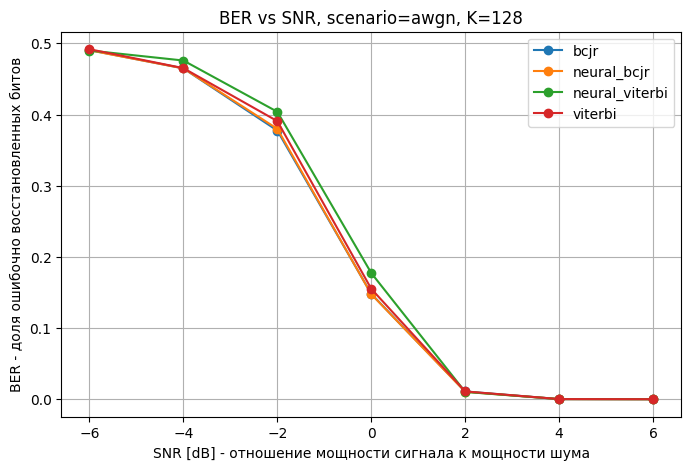

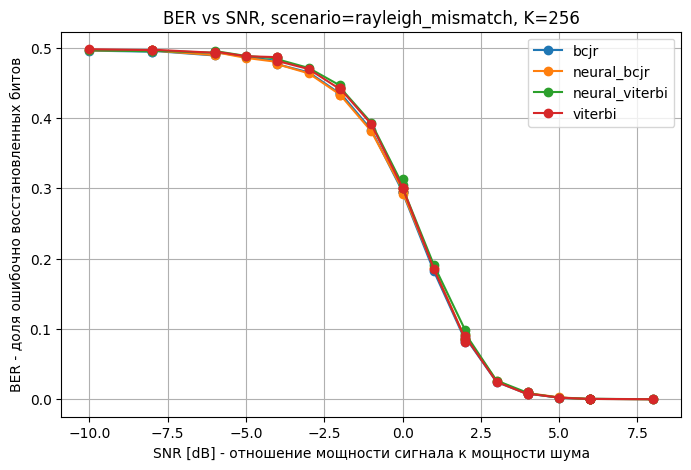

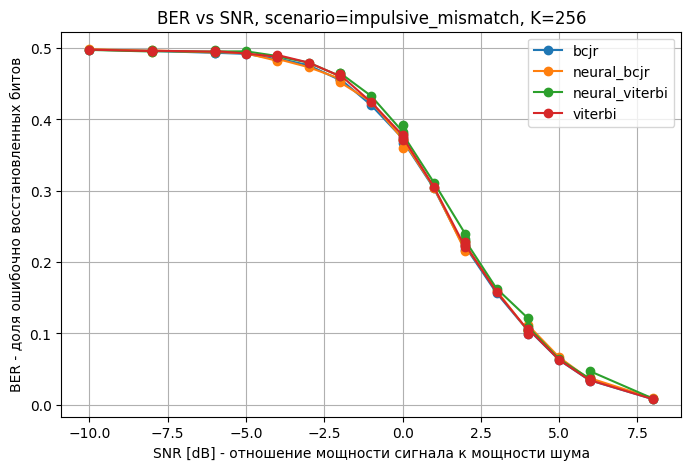

In [27]:
plot_scenario(research_df, "awgn", 128)
plot_scenario(research_df, "rayleigh_mismatch", 256)
plot_scenario(research_df, "impulsive_mismatch", 256)


neural_case_pair.to_csv("neural_case_pair.csv", index=False, encoding="utf-8-sig")
nv_case.to_csv("nv_case.csv", index=False, encoding="utf-8-sig")
nb_case.to_csv("nb_case.csv", index=False, encoding="utf-8-sig")
overall_case_table.to_csv("overall_case_table.csv", index=False, encoding="utf-8-sig")
wins_nv.to_csv("wins_nv.csv", index=False, encoding="utf-8-sig")
wins_nb.to_csv("wins_nb.csv", index=False, encoding="utf-8-sig")

print("Файлы сохранены.")



## 12. Итоговые прикладные выводы

### 12.1. Главный результат работы: сравнение Neural Viterbi и Neural BCJR

Основным предметом исследования в работе было сравнение двух обучаемых декодеров:
- **Neural Viterbi**
- **Neural BCJR**

Сравнение проводилось на совокупности всех исследованных сценариев:
- `awgn`
- `rayleigh`
- `amplitude_mismatch`
- `noise_mismatch`
- `burst`
- `impulsive_mismatch`
- `rayleigh_mismatch`

а также для различных размеров задачи (`K = 128, 256, 512, 1024`) и нескольких диапазонов SNR.

### Итог по двум neural-моделям

По совокупности экспериментов **Neural BCJR** является более сильной моделью **по качеству декодирования**, а **Neural Viterbi** — более сильной моделью **по скорости работы**.

Это подтверждается следующими результатами:

- по точечным сравнениям BER:
  - **Neural BCJR лучше Neural Viterbi в 207 точках**;
  - **Neural Viterbi лучше Neural BCJR в 40 точках**.

То есть по BER модель **Neural BCJR** выигрывает более чем в **5 раз чаще**, чем **Neural Viterbi**.

На уровне агрегирования по парам `(scenario, K)`:
- **Neural BCJR лучше Neural Viterbi по среднему BER во всех 20 агрегированных кейсах из 20**;
- при этом **Neural BCJR медленнее примерно в 3.0–3.7 раза**.

Средний выигрыш **Neural BCJR** по BER над **Neural Viterbi** по всем агрегированным кейсам составляет:

- **средняя delta BER = -0.00548**

Отрицательное значение означает, что BER у **Neural BCJR** ниже, то есть качество декодирования выше.

### Где преимущество Neural BCJR особенно заметно

Наиболее выраженный выигрыш **Neural BCJR** над **Neural Viterbi** наблюдается в следующих режимах:

- `rayleigh`, `K = 128`:  
  **delta BER = -0.011309**
- `awgn`, `K = 128`:  
  **delta BER = -0.009170**
- `noise_mismatch`, `K = 128`:  
  **delta BER = -0.008548**
- `rayleigh`, `K = 256`:  
  **delta BER = -0.008106**
- `amplitude_mismatch`, `K = 256`:  
  **delta BER = -0.006434**
- `amplitude_mismatch`, `K = 128`:  
  **delta BER = -0.006361**

То есть в ряде сценариев выигрыш **Neural BCJR** уже составляет не тысячные, а **сотые доли BER**, что является содержательно заметным эффектом.

### Где различие между Neural BCJR и Neural Viterbi мало

Есть и режимы, где разница по качеству между двумя neural-моделями становится небольшой. Наиболее близкие режимы:

- `impulsive_mismatch`, `K = 512`:  
  **delta BER = -0.002804**
- `rayleigh_mismatch`, `K = 512`:  
  **delta BER = -0.002914**

В этих сценариях **Neural BCJR** всё ещё лучше по BER, но выигрыш уже небольшой, тогда как по времени **Neural Viterbi** остаётся быстрее примерно в 3 раза. В таких режимах, если система чувствительна к времени декодирования, **Neural Viterbi** можно рассматривать как практически оправданный компромисс.

### Практический вывод по двум neural-подходам

Практически это означает следующее:

- если приоритетом является **качество декодирования**, то по совокупности всех исследованных кейсов предпочтительнее **Neural BCJR**;
- если приоритетом является **скорость работы**, а небольшое ухудшение качества допустимо, то предпочтительнее **Neural Viterbi**.

Иными словами:

- **Neural BCJR** — основной кандидат для режимов, где критично качество;
- **Neural Viterbi** — основной кандидат для режимов, где критична скорость.

---

### 12.2. Сравнение neural-моделей с классическими алгоритмами

Сравнение с классическими алгоритмами использовалось в работе как контрольная линия и инженерный ориентир.

#### Neural BCJR vs BCJR

По сравнению с классическим `bcjr` модель **Neural BCJR** показывает локальные выигрыши, но в среднем полностью baseline не превосходит.

По BER:
- **Neural BCJR выигрывает у BCJR в 87 точках**.

Наиболее сильный агрегированный кейс для **Neural BCJR**:

- `amplitude_mismatch`, `K = 128`  
  - `mean BER (BCJR) = 0.368356`
  - `mean BER (Neural BCJR) = 0.366481`
  - **delta BER = -0.001875**
  - **локальных побед = 6 из 8**

Это означает, что именно в этом режиме **Neural BCJR** уже не просто “близок” к baseline, а **в среднем лучше** классического `bcjr`.

При этом в ряде других сценариев разница между `bcjr` и `neural_bcjr` тоже мала:

- `burst`: **mean delta BER = +0.000253**
- `awgn`: **mean delta BER = +0.000369**
- `rayleigh_mismatch`: **mean delta BER = +0.000489**

То есть в этих сценариях `bcjr` формально остаётся лучше, но разрыв уже очень небольшой.

#### Neural Viterbi vs Viterbi

По сравнению с классическим `viterbi` модель **Neural Viterbi** также имеет локальные выигрыши:

- **Neural Viterbi выигрывает у Viterbi в 62 точках**.

Однако по агрегированным `(scenario, K)` кейсам **Neural Viterbi** в среднем baseline не превосходит. Наиболее близкий режим:

- `rayleigh_mismatch`, `K = 512`
  - `mean BER (Viterbi) = 0.290505`
  - `mean BER (Neural Viterbi) = 0.291103`
  - **delta BER = +0.000598**
  - **локальных побед = 2 из 8**

Это означает, что в этом режиме **Neural Viterbi** очень близок к классическому `viterbi` по качеству, но всё ещё немного уступает.

При этом нужно учитывать, что в текущей реализации:
- **Neural Viterbi медленнее Viterbi в среднем примерно в 1.34 раза**,
- **Neural BCJR медленнее BCJR в среднем примерно в 1.15 раза**.

Следовательно, если сравнивать neural-модели именно с их классическими аналогами, то:
- **Neural BCJR** является более перспективной моделью, потому что у неё уже есть сценарий с реальным средним выигрышем;
- **Neural Viterbi** пока скорее выступает как исследовательская learned-модификация, которая локально приближается к baseline, но ещё не формирует устойчивого преимущества.

---

### 12.3. Общий прикладной итог по всем четырём алгоритмам

Если смотреть на все четыре алгоритма одновременно (`viterbi`, `bcjr`, `neural_viterbi`, `neural_bcjr`), то нужно различать выводы по разным метрикам.

#### По BER
На уровне агрегированных `(scenario, K)` кейсов:
- **BCJR** является лучшим по BER в **19 из 20** случаев;
- только в одном кейсе лучшим по BER становится **Neural BCJR**:
  - `amplitude_mismatch`, `K = 128`.

#### По FER
По FER ситуация иная:
- **Viterbi** является лучшим по FER в **18 из 20** случаев.

#### По времени
По скорости:
- **Viterbi** является самым быстрым алгоритмом во **всех 20 из 20** агрегированных кейсов.

### Что это означает practically

Если задача ориентирована на:
- **минимизацию BER** — основным ориентиром остаётся **BCJR**;
- **скорость декодирования** — основным ориентиром остаётся **Viterbi**;
- **поиск наиболее сильной обучаемой модели** — лучшей learned-моделью является **Neural BCJR**;
- **быструю learned-модель** — такой моделью является **Neural Viterbi**.

---

### 12.4. Финальный прикладной вывод

Итог исследования можно сформулировать так:

1. Среди двух обучаемых алгоритмов:
   - **Neural BCJR** является предпочтительным, если приоритетом является **качество декодирования**;
   - **Neural Viterbi** является предпочтительным, если приоритетом является **скорость работы**.

2. Наиболее сильный practical-вывод в пользу neural-модели получен для:
   - `Neural BCJR` в сценарии **`amplitude_mismatch`, `K = 128`**,  
     где модель оказалась лучше классического `bcjr` в среднем по BER:
     **0.366481 против 0.368356**,  
     при **6 победах из 8 локальных точек**.

3. Для **Neural Viterbi** не найдено агрегированного `(scenario, K)` кейса, в котором он бы в среднем превосходил классический `viterbi`, однако найдены локальные выигрыши и режимы, где он становится очень близок к baseline.

4. Поэтому основной инженерный вывод работы выглядит так:
   - **Neural BCJR** — основной learned-кандидат для сложных и плохо моделируемых режимов;
   - **Neural Viterbi** — быстрый learned-компромисс;
   - **BCJR** и **Viterbi** остаются сильнейшими baseline-ориентирами на matched- и простых каналах.

Таким образом, с точки зрения ТЗ основным результатом работы является установление **практической области предпочтительного применения двух нейросетевых алгоритмов**:
- **Neural BCJR** — когда важнее качество;
- **Neural Viterbi** — когда важнее скорость.